In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd, csv, os

BASE = "/content/drive/MyDrive/amazon ml challenge/amazon ml"   # <-- your path (folder containing train/ and test/)
SAVE_DIR = f"{BASE}/new_parquet"
os.makedirs(SAVE_DIR, exist_ok=True)


In [3]:
def load(name, split="train"):
    pq = f"{SAVE_DIR}/{name}.parquet"
    if os.path.exists(pq):                       # already saved -> load fast
        df = pd.read_parquet(pq)
        print(f"{name}: {df.shape}  (from parquet)")
    else:                                        # first time -> read TSV and save parquet
        df = pd.read_csv(f"{BASE}/{split}/{split}_{name}.tsv", sep="\t", dtype="string[pyarrow]",
                         quoting=csv.QUOTE_NONE, keep_default_na=False, on_bad_lines="warn")
        df.to_parquet(pq, index=False)
        print(f"{name}: {df.shape}  (from TSV, saved parquet)")
    return df

s1, s2, s3, gt = [load(n) for n in ["source1", "source2", "source3", "ground_truth"]]

source1: (2206821, 4)  (from parquet)
source2: (5034616, 4)  (from parquet)
source3: (5285603, 4)  (from parquet)
ground_truth: (2206821, 2)  (from parquet)


In [4]:
# ground truth -> one row per true pair (also cached)
pq = f"{SAVE_DIR}/pairs.parquet"
if os.path.exists(pq):
    pairs = pd.read_parquet(pq)
    print("pairs: loaded from parquet")
else:
    pairs = gt.astype(object).assign(m_id=lambda d: d.matched_entity_ids.str.split(","))
    pairs = pairs.explode("m_id").rename(columns={"source1_entity_id": "s1_id"})[["s1_id", "m_id"]]
    pairs = pairs[pairs.m_id != ""].reset_index(drop=True)
    pairs.to_parquet(pq, index=False)
    print("pairs: built and saved parquet")

# country counts
print("\nCountries:\n", pd.DataFrame({"s1": s1.country.value_counts(),
                                      "s2": s2.country.value_counts(),
                                      "s3": s3.country.value_counts()}))

print("\nTrue pairs:", len(pairs), pairs.m_id.str[:2].value_counts().to_dict())

# matches per S1
n = gt.source1_entity_id.astype(object).map(pairs.s1_id.value_counts()).fillna(0).astype(int)
print("\nMatches per S1 (%):\n", (n.clip(upper=10).value_counts(normalize=True).sort_index() * 100).round(2))

# each S2/S3 belongs to only one S1?
print("\nS2/S3 ids under >1 S1:", pairs.m_id.duplicated().sum())
print("% of S2 matched:", round(100 * pairs.m_id.str.startswith("S2").sum() / len(s2), 1))
print("% of S3 matched:", round(100 * pairs.m_id.str.startswith("S3").sum() / len(s3), 1))

# is country same inside true pairs?
cmap = pd.concat([s1, s2, s3]).astype(object).set_index("entity_id").country
print("\nCountry S1 vs match:\n", pd.crosstab(pairs.s1_id.map(cmap), pairs.m_id.map(cmap)))

pairs: loaded from parquet

Countries:
               s1       s2       s3
country                           
US       1323633  3016817  3170056
India     883188  2017799  2115547

True pairs: 7638365 {'S3': 3944746, 'S2': 3693619}

Matches per S1 (%):
 source1_entity_id
0      5.58
1      5.40
2     17.00
3     24.05
4     21.94
5     14.59
6      7.47
7      2.90
8      0.85
9      0.19
10     0.03
Name: proportion, dtype: float64

S2/S3 ids under >1 S1: 0
% of S2 matched: 73.4
% of S3 matched: 74.6

Country S1 vs match:
 m_id     India       US
s1_id                  
India  3059843        0
US           0  4578522


1. Country is a perfect hard block. The crosstab has zeros off the diagonal: a true match never crosses countries. So rule #1 is to only compare records with the same country label. This is safe for France too, as long as we split by whatever label appears rather than hard-coding US/India.

The problem is still large, though. Inside the US alone that's 1.32M × 6.19M ≈ 8 trillion possible pairs, so we still need much tighter keys.

2. Almost every S1 has several matches. Only 5.6% are singletons, and most S1 records have 2–6 matches (about 3.5 on average, roughly half from S2 and half from S3). So each source contains duplicates of the same business. This helps later: once we confidently find one S2 match, the other S2 records that look like it are probably matches too.

3. Each S2/S3 belongs to exactly one S1 (0 violations). This is confirmed. At prediction time, if one S2 record looks like a match for two different S1 records, we give it only to the best one. That's a strong precision tool for F0.5.

4. About 26% of S2/S3 records match nothing (around 1.3M in each source). These unmatched records are the real danger. They are the "look-alike but different business" records that create false matches. We need to learn how they differ from the matched ones.

In [5]:
# ===== STEP 2: Field quality profile =====
import pandas as pd

matched_ids = set(pairs.m_id) | set(pairs.s1_id)

checks = {
    "name_empty":      ("name", r"^\s*$"),
    "addr_empty":      ("addr", r"^\s*$"),
    "name_devanagari": ("name", r"[\u0900-\u097F]"),
    "name_other_indic":("name", r"[\u0980-\u0DFF]"),          # Bengali, Tamil, Telugu, etc.
    "name_accents":    ("name", r"[À-ÿ]"),
    "addr_indic":      ("addr", r"[\u0900-\u0DFF]"),
    "name_domain":     ("name", r"(?i)\.(com|in|net|org|co|biz)\b|www\."),
    "name_dba":        ("name", r"(?i)\b(dba|d/b/a|aka|t/a)\b"),
    "name_junk":       ("name", r"#|\||--|\*|@|\$"),
    "name_legal_first":("name", r"(?i)^\s*(llc|inc|ltd|pvt|private|limited|corp|co)\b"),
    "name_legal_any":  ("name", r"(?i)\b(llc|inc|ltd|pvt|private|limited|corp|corporation|company|co|llp|plc)\b"),
    "addr_zip5":       ("addr", r"\b\d{5}(-\d{4})?\b"),
    "addr_pin6":       ("addr", r"\b\d{6}\b|\b\d{3}\s\d{3}\b"),
    "addr_has_digit":  ("addr", r"\d"),
    "addr_landmark":   ("addr", r"(?i)\b(near|nr|opp|opposite|behind|beside|next to|adj)\b"),
    "addr_po_box":     ("addr", r"(?i)\bp\.?\s?o\.?\s?box\b"),
}

rows = []
for src, df in [("S1", s1), ("S2", s2), ("S3", s3)]:
    d = df.sample(min(200_000, len(df)), random_state=0).astype(object).fillna("")
    d["matched"] = d.entity_id.isin(matched_ids)
    for (c, m), g in d.groupby(["country", "matched"]):
        f = {"name": g.business_name, "addr": g.business_address}
        r = {"col": f"{src}|{c}|{'M' if m else 'U'}", "n": len(g)}
        for k, (fld, pat) in checks.items():
            r[k] = round(100 * f[fld].str.contains(pat, regex=True).mean(), 1)
        r["name_all_upper"] = round(100 * ((g.business_name == g.business_name.str.upper())
                                           & g.business_name.str.contains("[A-Za-z]")).mean(), 1)
        r["name_words_med"] = g.business_name.str.split().str.len().median()
        r["addr_words_med"] = g.business_address.str.split().str.len().median()
        rows.append(r)

prof = pd.DataFrame(rows).set_index("col").T
pd.set_option("display.width", 250)
print(prof)

/tmp/ipykernel_582/1229968009.py:33: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  r[k] = round(100 * f[fld].str.contains(pat, regex=True).mean(), 1)
/tmp/ipykernel_582/1229968009.py:33: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  r[k] = round(100 * f[fld].str.contains(pat, regex=True).mean(), 1)
/tmp/ipykernel_582/1229968009.py:33: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  r[k] = round(100 * f[fld].str.contains(pat, regex=True).mean(), 1)
/tmp/ipykernel_582/1229968009.py:33: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  r[k] = round(100 * f[fld].str.contains(pat, regex=True).mean(), 1)
/tmp/ipykernel_582/1229968009.py:33: UserWar

col               S1|India|U  S1|India|M  S1|US|U   S1|US|M  S2|India|U  S2|India|M  S2|US|U  S2|US|M  S3|India|U  S3|India|M  S3|US|U  S3|US|M
n                     4552.0     75494.0   6696.0  113258.0     21312.0     58647.0  31884.0  88157.0     20385.0     59688.0  30437.0  89490.0
name_empty               0.0         0.0      0.0       0.0         0.0         0.0      0.0      0.0         0.0         0.0      0.0      0.0
addr_empty               0.0         0.0      0.0       0.0         0.2         3.9      0.4      4.8         0.3         4.1      0.3      4.6
name_devanagari          0.0         0.0      0.0       0.0        13.4        13.3      0.0      0.0         7.8         7.4      0.0      0.0
name_other_indic         0.0         0.0      0.0       0.0        10.2         9.9      0.0      0.0         5.9         5.6      0.0      0.0
name_accents             0.0         0.0      0.0       0.0         2.5         5.0      4.9      7.5         3.5         5.8      4.9  

This is a very revealing table. There are five findings, and the first one changes the plan.

1. Postal codes are almost never present

    US zip appears in only about 10% of records, and India PIN in only about 1%, even in S1. So postal code cannot be the main blocking key. It's a bonus when it exists. The main keys will have to come from:

    city + state (to check next)
    street number (100% of US S1 addresses have digits; 91% for India)
    name tokens

2. S1 is clean; S2 and S3 carry all the noise

    S1 has zero Indic script, zero junk, zero domains and zero all-caps names. So S1 is the clean reference, and the job is to bring S2/S3 back to S1's form.

3. Indic script is a major blocking problem for India
    About 23% of India S2 names are in Indic script (13% Devanagari plus 10% Tamil/Bengali/etc.), and about 13% in S3.
    About 23% of India S2/S3 addresses are also in Indic script.
    S1 has none. Without transliteration, any word-based rule will miss roughly 1 in 5 India S2 matches. Transliteration to Latin is mandatory before blocking.
4. The noise was added to matched records, not to unmatched ones

    Compare the M and U columns:

    Pattern       	       Matched   	         Unmatched

    empty address	           4–5%	              0.2–0.4%

    domain as name	         4.5–5.9%	          0.5–0.7%

    "dba" in name    	      1.3–1.9%(S3)          0%

    address has a digit	     87–88%	              99%

    all-caps name(S2)	       16–24%	            11–16%

    The unmatched records look like clean, S1-style records of other businesses, while the matched ones are noisy copies. Two consequences:

    Blocking needs a name-only path. About 5% of matched records have no address at all, and about 12% have no digit in the address, so any rule requiring street number or address would miss them.
    The level of noise is itself a useful signal for the model later.
5. Other details
    Legal suffixes are often dropped in the copies. India S1 has a suffix in 84% of names versus 55% in S2 matches; US is 49% vs 38%. So suffixes must be removed before blocking.
    Accents are injected noise in US names (5–7.5%, like Léarning and Béque), so accents should be stripped on both sides. This also handles French names.
    Landmarks ("near", "opp") appear only in India (about 12%), and PO Box only in the US (about 1.7%). Both are noise for blocking.
    Name length is 3–4 words. Address length is 9–11 words for India and 5–6 for the US.

(The warnings are harmless; they're about the regex groups.)

In [6]:
# ===== STEP 3: Side-by-side true pairs =====
m2s1 = pairs.set_index("m_id").s1_id

def show(s1_ids, title):
    print("\n" + "#" * 30, title, "#" * 30)
    sub = pairs[pairs.s1_id.isin(s1_ids)]
    recs = pd.concat([s1[s1.entity_id.isin(s1_ids)],
                      s2[s2.entity_id.isin(sub.m_id)],
                      s3[s3.entity_id.isin(sub.m_id)]]).astype(object).set_index("entity_id")
    for i in s1_ids:
        r = recs.loc[i]
        print("-" * 110)
        print(f"{i:14s} | {r.business_name}  ||  {r.business_address}")
        for m in sub[sub.s1_id == i].m_id:
            r = recs.loc[m]
            print(f"   {m:14s} | {r.business_name}  ||  {r.business_address}")

matched_s1 = s1[s1.entity_id.isin(set(pairs.s1_id))].astype(object)

# 1) random US clusters
show(matched_s1[matched_s1.country == "US"].entity_id.sample(10, random_state=1).tolist(), "US")

# 2) random India clusters
show(matched_s1[matched_s1.country == "India"].entity_id.sample(10, random_state=1).tolist(), "INDIA")

# 3) India clusters where a match has an Indic-script name
ind = s2[s2.country == "India"].sample(200_000, random_state=0).astype(object)
ind = ind[ind.business_name.str.contains(r"[\u0900-\u0DFF]") & ind.entity_id.isin(m2s1.index)]
show(ind.entity_id.map(m2s1).drop_duplicates().sample(6, random_state=1).tolist(), "INDIA - INDIC SCRIPT")


############################## US ##############################
--------------------------------------------------------------------------------------------------------------
S1-189241008   | Lyrari Oceanhawk LLC  ||  148 Wells Road, Huntington, NY
   S3-155142836   | Lyrari LLC Services  ||  New York, Huntington, 148 Wells Rd
   S3-159977435   | Lyrari Oceanhawk  ||  148 Wells Road, Huntington, New York
--------------------------------------------------------------------------------------------------------------
S1-713736045   | Physical Therapy Pinnacle Group Center  ||  623 Cain Road, Somerville, AL
   S2-759384098   | @physicaltherapy  ||  623 CAIN RD, PMB 5281, SOMERVILLE, AL
   S2-799076608   | Physical Therapy Pinnacle Group Center  ||  623 CAIN RD, SOMERVILLE, AL
   S3-313590742   | Physical Therapy Pinnacle Group Ccder (ID: 92399)  ||  62 Cain Road, Somerville, Alabama
-----------------------------------------------------------------------------------------------------------

This sample shows almost every noise type. Here's the catalogue, since each item becomes a cleaning or blocking decision.

Name noise

    Legal suffix dropped / added / moved to front--->	INC SIGNATURE…, Inc. Rocky Keystone Health, (LIMITED) SHIVA, Prívate Universal Ventures Limited

    Filler words added	Services, Center, Co, (Service), Limited Limited, (ID: 92399)

    Honorific prefixes	M/s, Sri, Shri, Mr, The

    OCR-style digit swaps	8low (B→8), Crysta1 (l→1), 6OODRIDGE (G→6)

    Heavy typos (several letters)	Hearhlh, HARALLTH, GEETIBS, Consultgtancy, Esedgy

    Injected accents	Héalth, ÍNC, MÍDLAND

    Hyphens, double spaces	Walker-Culture, Dd-& Co

    Word order shuffled	Trg Titan Inc, Dd Co &, ZEPHEON LLC MÍDLAND

    Words dropped	Oncology Metropolitan, Crystal Services

    Domain / handle as name	blowwalkerculture.com, @physicaltherapy, shprivate.com (an acronym)

    Full script change	Malayalam, Tamil, Devanagari, Bengali, and mixed (सन Power Pvt Ltd)

    Completely different name	Zetavantageumbra, Sollyra, Irihalo, Goodridge Anigadha, all with the correct address

Address noise

    Street abbreviations	Road↔Rd, Drive↔DR, Terrace↔TER, North↔N, Street→SAINT (wrong expansion)

    Numbers as words	21st ↔ TWENTY FIRST

    State short forms	NY↔New York, UP, TN, KL, GJ, HR, WB, DL, MP

    State in native script	കേരളം, उत्तर प्रदेश, महाराष्ट्र, ગુજરાત, தமிழ்நாடு

    Components reordered	NC, Smithfield, 270 Equity Drive

    Junk inserted	PMB 5281, PO Box 6896, N/A, null, #719, H.NO, ##

    Street/house number corrupted	623→62, 8216→8227/8212, 54th→54rd, 270→270-A, 293A→00293A, 306→30, 1/694→1/69

    City variants / aliases	LANCSTER CITY, Geensboro, Gurgaon↔Gurugram, Kolkata↔Calcutta, Aurangabad↔Chhatrapati Sambhaji Nagar

    Wrong district inserted	Sivaganga in a Chennai address, Villupuram in an Ambattur one

    Heavy truncation	No 11/12, Velachery, Chennai, TN, Howrah, Kolkata, WB, 25

    Empty address	several examples

What this means for blocking-----
We need two independent paths, name and address. Some matches have a completely random name but the right address, and others have the right name and an empty address. Any single rule needing both fields will miss one kind. A candidate should get in if either path finds it.
Exact street number isn't safe as a key. It's corrupted often enough that we must measure how often it agrees exactly, and also check looser forms like the first 2–3 digits or stripped leading zeros.
State is the most reliable location field, once we map abbreviations and native script. City is next, but it needs an alias map and typo tolerance.
Transliteration will be imperfect. Southern → सदर्न → roughly "sadarn". So Indic names need fuzzy keys (character n-grams or phonetic codes), not exact tokens. Luckily their addresses are usually in Latin script, so the address path can save them.
Typos are multi-letter, so a single-edit tolerance won't be enough. Character n-gram similarity is the natural fit.

In [7]:
# ===== STEP 4: Mine substitutions / insertions / deletions from true pairs =====
import re, unicodedata
from collections import Counter

def toks(s):
    s = unicodedata.normalize("NFKD", s or "")
    s = re.sub(r"[\u0300-\u036f]", "", s)                  # strip Latin accents only (keeps Indic intact)
    return re.findall(r"[a-z0-9]+|[^\x00-\x7f\s,.\-#/()&|@*]+", s.lower())

# 300k random true pairs with text for both sides
sp = pairs.sample(300_000, random_state=0)
rec = pd.concat([s1[s1.entity_id.isin(sp.s1_id)],
                 s2[s2.entity_id.isin(sp.m_id)],
                 s3[s3.entity_id.isin(sp.m_id)]]).astype(object).set_index("entity_id")
sp = sp.join(rec.add_prefix("a_"), on="s1_id").join(rec.add_prefix("b_"), on="m_id")

def fmt(counter, k, arrow=False):
    return "  ".join(f"{a}→{b}:{c}" if arrow else f"{a}:{c}"
                     for (a, b), c in [(x if arrow else (x, None), c) for x, c in counter.most_common(k)])

for field in ["business_name", "business_address"]:
    for ctry in ["US", "India"]:
        g = sp[sp.a_country == ctry]
        subs, ins, dels = Counter(), Counter(), Counter()
        exact = same_lower = same_set = 0
        for a, b in zip(g["a_" + field], g["b_" + field]):
            ta, tb = toks(a), toks(b)
            exact += (a == b); same_lower += (ta == tb); same_set += (set(ta) == set(tb))
            A, B = set(ta) - set(tb), set(tb) - set(ta)
            ins.update(B); dels.update(A)
            if A and B and len(A) <= 3 and len(B) <= 3:
                subs[(" ".join(sorted(A)), " ".join(sorted(B)))] += 1
        n = len(g)
        print("\n" + "=" * 110)
        print(f"{field} | {ctry} | pairs={n:,}")
        print(f"exact raw: {100*exact/n:.1f}%   same tokens same order: {100*same_lower/n:.1f}%   "
              f"same token SET (order ignored): {100*same_set/n:.1f}%")
        print("\nTOP SUBSTITUTIONS (S1 → match):\n", fmt(subs, 60, arrow=True))
        print("\nTOP INSERTED words (in match, not in S1):\n", fmt(ins, 50))
        print("\nTOP DROPPED words (in S1, not in match):\n", fmt(dels, 50))


business_name | US | pairs=179,805
exact raw: 5.9%   same tokens same order: 30.4%   same token SET (order ignored): 37.6%

TOP SUBSTITUTIONS (S1 → match):
 llc→c l:2249  inc→incorporated:1599  c l→llc:380  pllc→c l p:279  pc→inc:194  corp→corporation:185  group→llc:176  pc→llc:163  group→inc:160  c p→inc:143  c p→llc:131  lp→llc:105  lp→inc:104  inc→lnc:96  corporation→corp:95  llc→com:70  company→co:64  c p→pc:61  associates→center:60  partners→center:58  center→centre:58  co→company:54  center→services:48  holdings→inc:48  holdings→llc:47  partners→services:45  care→services:45  inc→com:43  clinic→center:42  care→center:40  and→center:38  associates→services:36  care→ce:35  llc→l1c:31  health→center:31  and llc→c l:30  specialists→center:29  associates→ass0ciates:28  care→service:26  associates→service:26  dental→denta1:25  and→services:25  llc→and c l:24  health→hea1th:23  specialists→services:22  health→services:22  s→5:22  center→service:22  services→center:22  partners→service:

What the substitutions reveal:

    llc → c l (2,249 times) comes from dotted forms. L.L.C. split into letters. The same goes for P.L.L.C., P.C. and L.P.. Decision: join dotted initials (and runs of single letters) back into one word before anything else.

    Legal suffixes are swapped between types, not just shortened: pc→inc, lp→llc, group→llc, holdings→inc, limited→ltd. Decision: remove all legal forms for blocking. They carry no identity. I'll also include French forms (SARL, SAS, SA, EURL, SASU, SCI, SNC) now, so the test set's France isn't hurt.

    A generic word gets replaced by filler. associates / partners / care / clinic / health / private → center / services / service. The inserted fillers are center, centre, services, service. Decision: test removing these four; measured below.

    OCR-style digit swaps: hea1th, fami1y, capita1, c1inic, denta1, ass0ciates, 5ervices, l1c, c0m. Decision: inside words that mix letters and digits, map 0→o, 1→l, 5→s, 8→b, 6→g.

    Alias markers: dba, aka, formerly, fka, nee, doing business as, known as, (ID: …). Decision: remove the marker words but keep both names' words.

    Domains: com was inserted 10,191 times, plus www and c0m. Decision: strip www. and .com/.in/.net…, and keep the joined core word (like blowwalkerculture). Splitting that core word needs character n-grams, which comes later.

    India honorifics: mr, smt, shri, sri, dr, m/s. Decision: remove them. shree stays, since it's often part of the real name (Shreeji).

    Indic legal words (लिमिटेड, प्राइवेट, प्रा, लि, and the Tamil, Telugu, Kannada, Bengali, Gujarati, Malayalam and Odia forms) are among the most inserted words. Decision: remove them by list now; full transliteration gets its own step.

    india gets dropped from names (and appears as lndia). Decision: test removing it in India names.

Addresses (for the next step)

    US: standard abbreviations (road→rd, street→st, drive→dr, avenue→ave…), and street→saint (319 times), so map both to st. State codes and full names are swapped constantly. unit was dropped 19,091 times, and apt/apartment too, so units are unreliable for blocking. city, county, town, township, cdp, of get added or dropped around city names. null, pmb, po box are junk.

    India: state appears as full name, 2-letter code or native script, plus old names (orissa↔odisha, keralam). telangana → andhra pradesh (315 times), so Telangana and AP must count as the same state. Delhi districts (south, west, central) are replaced with दिल्ली. City aliases: bombay↔mumbai, poona↔pune, bangalore↔bengaluru, gurgaon↔gurugram. House-number prefixes (no, door, h, hn, plot, block) are added or swapped. Many parts get dropped (floor, flat, near, sector, colony).
Only about 13% of address pairs have the same word set, even ignoring order. So blocking can't use the whole address; it has to use individual parts (state, locality, numbers).

In [8]:
# ===== STEP 5: Name normalization (v1, v2) + measurement on true pairs =====
import re, unicodedata, numpy as np
from collections import Counter

def base(s):
    s = unicodedata.normalize("NFKC", s or "").lower()
    s = unicodedata.normalize("NFKD", s)
    return re.sub(r"[\u0300-\u036f]", "", s)          # strip Latin accents, keep Indic

LEGAL = set("""llc inc incorporated corp corporation co company cos ltd limited pvt private llp lp lllp
pc pllc plc pa psc gmbh ag sa sarl sas sasu eurl sci snc""".split())
HONOR = set("mr mrs ms smt shri sri dr the a an of and".split())
INDIC_LEGAL = {base(w) for w in """लिमिटेड प्राइवेट प्रा लि एलएलपी లిమిటెడ్ ప్రైవేట్ ಲಿಮಿಟೆಡ್ ಪ್ರೈವೇಟ್
லிமிடெட் பிரைவேட் লিমিটেড প্রাইভেট લિમિટેડ પ્રાઇવેટ ലിമിറ്റഡ് പ്രൈവറ്റ് ଲିମିଟେଡ୍ ପ୍ରାଇଭେଟ୍""".split()}
FILLER = {"center", "centre", "services", "service", "india"}

ID_RE   = re.compile(r"\(?\bid\s*[:#]?\s*\d+\s*\)?")
DOM_RE  = re.compile(r"\bwww\.|\.(com|net|org|in|co|biz|info|us)\b")
MS_RE   = re.compile(r"\bm\s*/\s*s\b")
MARK_RE = re.compile(r"\b(d\s*/?\s*b\s*/?\s*a|a\s*/?\s*k\s*/?\s*a|f\s*/?\s*k\s*/?\s*a|nee|t\s*/\s*a|"
                     r"formerly(\s+known\s+as)?|doing\s+business\s+as|also\s+known\s+as|known\s+as|trading\s+as)\b")
DOT_RE  = re.compile(r"\b(?:[a-z]\s*\.\s*){2,}(?:[a-z]\b)?")
OCR     = str.maketrans("01568", "olsbg")

def norm_name(s, v=2):
    s = base(s)
    s = ID_RE.sub(" ", s); s = DOM_RE.sub(" ", s); s = MS_RE.sub(" ", s); s = MARK_RE.sub(" ", s)
    s = s.replace("&", " and ").replace("@", " ")
    s = DOT_RE.sub(lambda m: " " + re.sub(r"[^a-z]", "", m.group(0)) + " ", s)
    s = re.sub(r"[^\w\s\u0900-\u0DFF]|_", " ", s)
    t = [x.translate(OCR) if (re.search(r"[a-z]", x) and re.search(r"\d", x)) else x for x in s.split()]
    out, run = [], []                                   # collapse runs of single letters: "l l c" -> "llc"
    for x in t + [""]:
        if len(x) == 1 and x.isalpha(): run.append(x); continue
        if run: out.append("".join(run) if len(run) > 1 else run[0]); run = []
        if x: out.append(x)
    drop = LEGAL | HONOR | INDIC_LEGAL | {"com", "www"} | (FILLER if v >= 2 else set())
    out = [x for x in out if x not in drop]
    if v >= 2: out = [x for x in out if len(x) > 1 or x.isdigit()]
    return out

def raw_toks(s):                                        # same as Step 4 (baseline)
    s = base(s)
    return re.findall(r"[a-z0-9]+|[^\x00-\x7f\s,.\-#/()&|@*]+", s)

has_indic = lambda s: bool(re.search(r"[\u0900-\u0DFF]", s or ""))

print(f"{'country':8s}{'version':8s}{'same_set%':>10s}{'jacc_mean':>10s}{'jacc_med':>9s}{'share>=1%':>10s}{'zero_share%':>12s}")
zero_rows = {}
for ctry in ["US", "India"]:
    g = sp[sp.a_country == ctry]
    for ver, fn in [("raw", raw_toks), ("v1", lambda s: norm_name(s, 1)), ("v2", lambda s: norm_name(s, 2))]:
        A = [set(fn(x)) for x in g.a_business_name]; B = [set(fn(x)) for x in g.b_business_name]
        jac = np.array([len(a & b) / len(a | b) if (a | b) else 1.0 for a, b in zip(A, B)])
        share = np.array([len(a & b) > 0 for a, b in zip(A, B)])
        print(f"{ctry:8s}{ver:8s}{100*np.mean([a == b for a, b in zip(A, B)]):10.1f}{jac.mean():10.3f}"
              f"{np.median(jac):9.3f}{100*share.mean():10.1f}{100*(~share).mean():12.1f}")
        if ver == "v2":
            zero_rows[ctry] = (g[~share], A, B, share)

# ---- what is still failing under v2? ----
for ctry, (z, A, B, share) in zero_rows.items():
    n = len(z)
    indic = z.b_business_name.map(has_indic)
    print("\n" + "=" * 100)
    print(f"{ctry}: pairs with ZERO shared name tokens after v2 = {n:,}")
    print(f"  match name in Indic script: {100*indic.mean():.1f}%   Latin: {100*(~indic).mean():.1f}%")
    print("  20 random Latin zero-share examples (S1  →  match):")
    for a, b in z[~indic].sample(min(20, (~indic).sum()), random_state=0)[["a_business_name", "b_business_name"]].values:
        print(f"    {a:45s} → {b}")

    subs = Counter()
    for a, b, s in zip(A, B, share):
        d1, d2 = a - b, b - a
        if d1 and d2 and len(d1) <= 2 and len(d2) <= 2:
            subs[(" ".join(sorted(d1)), " ".join(sorted(d2)))] += 1
    print(f"\n  TOP remaining substitutions after v2 ({ctry}):")
    print("  " + "  ".join(f"{a}→{b}:{c}" for (a, b), c in subs.most_common(40)))

country version  same_set% jacc_mean jacc_med share>=1% zero_share%
US      raw           37.6     0.703    0.750      92.0         8.0
US      v1            62.0     0.780    1.000      91.7         8.3
US      v2            63.3     0.791    1.000      91.6         8.4
India   raw           24.4     0.549    0.600      75.9        24.1
India   v1            53.4     0.638    1.000      75.6        24.4
India   v2            55.5     0.653    1.000      75.5        24.5

US: pairs with ZERO shared name tokens after v2 = 15,120
  match name in Indic script: 0.0%   Latin: 100.0%
  20 random Latin zero-share examples (S1  →  match):
    Parker Restaurant Inc                         → parkerrestaurant.com
    Congregation Zion                             → congregationzion.com
    Decarlo Heritage Electric LLC                 → Fayeyuma
    Willett Diamond Wellness Inc                  → willettdiamondwellness.com
    Urology Physicians of Upper Marlboro          → upupper.com
    Gulf Co

The cleaning is a big win. The same-set rate nearly doubled, and now more than half of all true pairs have identical word sets after cleaning.

    Why "share ≥1" dipped slightly, and why that's fine: in raw form, many pairs shared only a word like llc or limited. Those shared words were useless for blocking anyway; a block keyed on llc holds a million records. v2 removed that fake overlap. So v2 is keeping v2.
What still fails (zero shared words after v2)

US, 8.4% of pairs, all Latin script. From the examples, there are three kinds:

    Concatenated names, the majority: parkerrestaurant.com, #GULFCOLLEGE, footankle.com, chavezodonnellmartinez.com, GREATPROJECTII.COM. The words are all there, just glued together.

        Fix: compare names with spaces removed (prefix/substring) and with character n-grams.

    Completely random names: Fayeyuma, Jaxsol. No name rule can ever catch these. Only the address path can.

        Typo in every word of short names: Jasper → JASME. Character n-grams help partly.

India, 24.5% of pairs:

    70% of those are Indic script, which is about 17% of all India pairs. This is the biggest single gap and needs transliteration (next step).

    The other 30% are the same three kinds as the US (classicbuilders.com, Veradeltayuma).

Remaining substitutions: new patterns
    OCR letter confusions: b↔g (breat, broup, blobal, grothers, gusiness), i↔l (lnstitute, lndustries, lst), rn↔m (comerstone, westem, northem, intemational), cl↔d (pinnade). Fix: a "folded" key where these look-alikes are treated as the same letter, used only for blocking keys.

    Singular/plural: associates→associate, technologies→technology, industries→industry. Fix: a light plural strip.

    partners is another filler word, replacing care, clinic, medicine, alliance, brothers, foundation and others.
     Fix: add partners/partner to the fillers.

    Professional credentials: ph→phd, dds, md, do. Fix: remove them like legal words.

    Mixed Indic and English: global→ग्लोबल, finance→फाइनेंस. Transliteration will fix these.


**Step 6: Name v3 plus the "glued name" and fuzzy keys**

This step tests each fix separately, so we can see how much each one recovers. Indic-script pairs are reported separately because they need transliteration, which comes in Step 7.

tok_v2: baseline from the last step
tok_v3: v2 plus the partners filler, credentials removed, plural strip
tok_v3_fold: v3 plus OCR look-alike folding
concat: names with spaces removed are a substring of each other, or share their first 6 characters
ngram: character 3-gram Jaccard ≥ 0.3 on the glued names
ANY: found by at least one of the above

In [9]:
# ===== STEP 6: Name v3 + fold + concat + char n-gram recovery =====
FILLER3 = FILLER | {"partners", "partner"}
CRED = set("md do dds dmd phd cpa esq rn dc od dpm dvm lcsw".split())
FOLD = str.maketrans("gl", "bi")

def stem(x):
    if len(x) > 4 and x.endswith("ies"): return x[:-3] + "y"
    if len(x) > 3 and x.endswith("s") and not x.endswith("ss"): return x[:-1]
    return x

def fold(x):
    return x.replace("rn", "m").replace("cl", "d").replace("vv", "w").translate(FOLD)

def norm_name3(s):
    return [stem(x) for x in norm_name(s, 2) if x not in FILLER3 | CRED]

def grams(s, n=3):
    return {s[i:i+n] for i in range(max(len(s) - n + 1, 1))} if s else set()

rows, leftovers = [], {}
for ctry in ["US", "India"]:
    g = sp[sp.a_country == ctry]
    indic = g.b_business_name.map(has_indic).values
    A2 = [set(norm_name(x, 2)) for x in g.a_business_name]; B2 = [set(norm_name(x, 2)) for x in g.b_business_name]
    A3 = [norm_name3(x) for x in g.a_business_name];         B3 = [norm_name3(x) for x in g.b_business_name]
    AF = [{fold(t) for t in a} for a in A3];                 BF = [{fold(t) for t in b} for b in B3]
    JA = [fold("".join(a)) for a in A3];                     JB = [fold("".join(b)) for b in B3]

    tok2  = np.array([len(a & b) > 0 for a, b in zip(A2, B2)])
    tok3  = np.array([len(set(a) & set(b)) > 0 for a, b in zip(A3, B3)])
    tokf  = np.array([len(a & b) > 0 for a, b in zip(AF, BF)])
    conc  = np.array([bool(a and b) and (a in b or b in a or a[:6] == b[:6]) for a, b in zip(JA, JB)])
    ng    = np.array([len(grams(a) & grams(b)) / max(len(grams(a) | grams(b)), 1) for a, b in zip(JA, JB)])
    ngok  = ng >= 0.3
    anyok = tokf | conc | ngok

    for grp, mask in [("Latin", ~indic), ("Indic", indic)]:
        if mask.sum() == 0: continue
        rows.append([ctry, grp, mask.sum()] + [round(100 * m[mask].mean(), 1)
                     for m in [tok2, tok3, tokf, conc, ngok, anyok]])
    leftovers[ctry] = (g[~anyok & ~indic], ng[~anyok & ~indic])

print(pd.DataFrame(rows, columns=["country", "script", "pairs", "tok_v2", "tok_v3", "tok_v3_fold",
                                  "concat", "ngram>=0.3", "ANY"]).to_string(index=False))

for ctry, (z, ngz) in leftovers.items():
    print("\n" + "=" * 100)
    print(f"{ctry} Latin pairs NOT recovered by any name key: {len(z):,}  "
          f"(of which char-3gram Jaccard < 0.1, i.e. likely random name: {100*(ngz < 0.1).mean():.1f}%)")
    for a, b in z.sample(min(25, len(z)), random_state=1)[["a_business_name", "b_business_name"]].values:
        print(f"    {a:50s} → {b}")

country script  pairs  tok_v2  tok_v3  tok_v3_fold  concat  ngram>=0.3  ANY
     US  Latin 179805    91.6    91.6         91.6    92.6        95.1 97.6
  India  Latin  98174    91.0    91.0         91.0    93.3        91.9 96.9
  India  Indic  22021     6.4     6.4          6.4     2.3         3.1  6.4

US Latin pairs NOT recovered by any name key: 4,322  (of which char-3gram Jaccard < 0.1, i.e. likely random name: 83.7%)
    Surgical Clinic of Clarksville, LLC                → Fayepyra
    Cairistiona Moore, D.C.                            → Fluxnexwex
    N+ Diana                                           → N+ Dnaia
    Blue Center                                        → Quokelo
    Halcyon Lafayette Inc                              → Véoiri
    Transcontinental Robotics Products Inc             → Ca1obelo
    Irene Navarro Gas Care                             → Avidelta
    Golden Vanguard Strategy, Inc.                     → gvstrategy.com
    Ear Nose & Throat Complete Associates

    Plural stripping and OCR folding add nothing to "shares ≥1 word". Typos usually hit one word, and the pair still shares another. They may still matter when a blocking key uses one specific word, like the rarest word, so we'll re-test them in rule scoring. Keep them as options for now.

    The glued-name key (concat) adds +2.3 points, and all the keys together reach about 97% for Latin-script names. That's the name-path ceiling.

What's left is almost all synthetic random names

    84% (US) and 92% (India) of the unrecovered pairs have essentially no character overlap. They look like Fayepyra, Fluxnexwex, Quokelo, Nylabrix, Pyraonyxvio, Drexlumflux, Zetavio.

    These are generated from a fixed set of syllables: pyra, lyra, jax, nexa/nex, wex, zeph, orbi, kelo, belo, tavo, drex, flux, halo, brix, onyx, riza, zeta, yuma, delta, vio/veo, mira. That's useful in two ways:

    A random-name detector is possible: if a name is built only from these syllables, its name is pure noise. Blocking must then rely on the address, and the model should ignore the name.
We must check (in the look-alike step) whether unmatched records also get such names. If only matched records do, that's another signal.

    The rest are acronyms: gvstrategy, DBP, BS, WI, iyprivate, gdass0ciates. An initials key only works combined with the address, since 2–3 letters alone make huge blocks. It's a small gain, so it's low priority.

Indic script is the big gap

    India Indic: only 6.4% share a word. That's 22,021 pairs, about 18% of all India pairs. Transliteration is the most important name fix left.

In [10]:
# ===== STEP 7: Indic transliteration - dictionary vs rules vs phonetic skeleton =====
!pip -q install indic_transliteration
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate
from functools import lru_cache

SCRIPTS = [(0x0900,0x097F,sanscript.DEVANAGARI),(0x0980,0x09FF,sanscript.BENGALI),
           (0x0A00,0x0A7F,sanscript.GURMUKHI),(0x0A80,0x0AFF,sanscript.GUJARATI),
           (0x0B00,0x0B7F,sanscript.ORIYA),(0x0B80,0x0BFF,sanscript.TAMIL),
           (0x0C00,0x0C7F,sanscript.TELUGU),(0x0C80,0x0CFF,sanscript.KANNADA),
           (0x0D00,0x0D7F,sanscript.MALAYALAM)]

def script_of(w):
    for ch in w:
        o = ord(ch)
        for lo, hi, sc in SCRIPTS:
            if lo <= o <= hi: return sc
    return None

@lru_cache(maxsize=None)
def translit(w):
    sc = script_of(w)
    if sc is None: return w
    x = transliterate(unicodedata.normalize("NFC", w), sc, sanscript.IAST)
    x = x.replace("ṃ", "n").replace("ṁ", "n").replace("ḥ", "").replace("ṛ", "ri")
    x = re.sub(r"[^a-z]", "", base(x))
    if len(x) > 3 and x.endswith("a") and x[-2] not in "aeiou": x = x[:-1]   # schwa deletion
    return x

VOW = "aeiou"
@lru_cache(maxsize=None)
def skel(w, voice=False):
    w = re.sub(r"[^a-z]", "", w)
    if not w: return ""
    w = re.sub(r"c(?=[eiy])", "s", w)
    for a, b in [("ph","f"),("bh","b"),("dh","d"),("th","t"),("kh","k"),("gh","g"),("sh","s"),
                 ("ch","c"),("jh","j"),("ck","k"),("w","v"),("q","k"),("x","ks"),("z","j"),("c","k"),("y","i")]:
        w = w.replace(a, b)
    if voice: w = w.translate(str.maketrans("dbg", "tpk"))
    out = w[0] + "".join(ch for ch in w[1:] if ch not in VOW)
    return re.sub(r"(.)\1+", r"\1", out)

# ---------- 1) learn dictionary on companies NOT in the evaluation sample ----------
eval_s1 = set(sp.s1_id)
ind_recs = pd.concat([s2[s2.country == "India"], s3[s3.country == "India"]])
# FIX: Replace raw string Unicode escape with f-string to use actual Unicode characters
ind_recs = ind_recs[ind_recs.business_name.str.contains(f"[{chr(0x0900)}-{chr(0x0DFF)}]")].astype(object)
lp = pairs[~pairs.s1_id.isin(eval_s1) & pairs.m_id.isin(set(ind_recs.entity_id))]
lp = lp.join(ind_recs.set_index("entity_id").business_name.rename("b"), on="m_id")
s1_names = s1[s1.entity_id.isin(set(lp.s1_id))].astype(object).set_index("entity_id").business_name
lp = lp.join(s1_names.rename("a"), on="s1_id")
print("dictionary learning pairs:", len(lp))

cnt, freq = Counter(), Counter()
for a, b in zip(lp.a, lp.b):
    ta = set(norm_name3(a)); tb = {x for x in norm_name3(b) if has_indic(x)}
    freq.update(tb)
    for x in tb:
        for y in ta: cnt[(x, y)] += 1
best = {}
for (x, y), c in cnt.items():
    if c >= 5 and c / freq[x] >= 0.5 and c > best.get(x, ("", 0))[1]:
        best[x] = (y, c)
DICT = {x: y for x, (y, c) in best.items()}
print("dictionary size:", len(DICT))
print("sample entries:", "  ".join(f"{x}→{y}({c})" for x, (y, c) in
                                  sorted(best.items(), key=lambda kv: -kv[1][1])[:40]))

# ---------- 2) evaluate on held-out Indic pairs ----------
g = sp[(sp.a_country == "India") & sp.b_business_name.map(has_indic)]
A = [norm_name3(x) for x in g.a_business_name]
B = [norm_name3(x) for x in g.b_business_name]
indic_toks = [t for b in B for t in b if has_indic(t)]
print(f"\neval Indic pairs: {len(g):,} | Indic tokens covered by dictionary: "
      f"{100*np.mean([t in DICT for t in indic_toks]):.1f}%")

TR  = [[translit(t) for t in b] for b in B]                           # rules only
DTR = [[DICT.get(t) or translit(t) for t in b] for b in B]            # dictionary first, rules fallback

def share(X, Y, f=lambda t: t):
    return np.array([len({f(t) for t in x} & {f(t) for t in y}) > 0 for x, y in zip(X, Y)])
def ngram_ok(X, Y, th=0.3):
    out = []
    for x, y in zip(X, Y):
        ga, gb = grams("".join(x)), grams("".join(y))
        out.append(len(ga & gb) / max(len(ga | gb), 1) >= th)
    return np.array(out)

res = {
    "no_translit":      share(A, B),
    "dict_only":        share(A, [[DICT.get(t, t) for t in b] for b in B]),
    "rules_exact":      share(A, TR),
    "rules_skel":       share(A, TR, skel),
    "rules_skel_voice": share(A, TR, lambda t: skel(t, True)),
    "dict+rules_skel":  share(A, DTR, skel),
    "dict+rules_skelV": share(A, DTR, lambda t: skel(t, True)),
    "dict+rules_ngram": ngram_ok(A, DTR),
}
res["ANY"] = np.logical_or.reduce(list(res.values()))
print("\n% of Indic pairs sharing >=1 token:")
for k, v in res.items(): print(f"  {k:18s} {100*v.mean():5.1f}%")

# ---------- 3) sanity: transliteration examples + failures ----------
print("\nTransliteration examples (Indic → rules → S1):")
for i in np.random.RandomState(0).choice(len(g), 12, replace=False):
    print(f"  {g.b_business_name.iloc[i]:40s} → {' '.join(TR[i]):30s} | {g.a_business_name.iloc[i]}")
print("\nStill NOT recovered (Indic → dict+rules → S1):")
fail = np.where(~res["ANY"])[0]
print(f"  count: {len(fail):,} ({100*len(fail)/len(g):.1f}%")
for i in np.random.RandomState(1).choice(fail, min(15, len(fail)), replace=False):
    print(f"  {g.b_business_name.iloc[i]:40s} → {' '.join(DTR[i]):30s} | {g.a_business_name.iloc[i]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.9/162.9 kB 7.1 MB/s eta 0:00:00
dictionary learning pairs: 466120
dictionary size: 1315
sample entries: इंटरनेशनल→international(8173)  टेक→tech(8043)  ग्लोबल→global(7942)  बिल्डर्स→builder(5424)  इंफ्रास्ट्रक्चर→infrastructure(5409)  ट्रेडिंग→trading(5382)  सॉल्यूशंस→solution(5344)  आईटी→it(5322)  प्रोड्यूसर→producer(5311)  कंसल्टिंग→consulting(5294)  इंजीनियरिंग→engineering(5289)  पावर→power(5287)  मैनेजमेंट→management(5276)  बिजनेस→business(5272)  कंसल्टेंट्स→consultant(5268)  प्रोडक्ट्स→product(5268)  एनर्जी→energy(5267)  इंडस्ट्रीज→industry(5257)  एक्सपोर्ट्स→export(5240)  फाउंडेशन→foundation(5226)  इम्पेक्स→impex(5225)  फाइनेंस→finance(5213)  इंफ्रा→infra(5207)  डेवलपर्स→developer(5202)  सॉफ्टवेयर→software(5185)  मीडिया→media(5184)  प्रोजेक्ट्स→project(5182)  एग्रो→agro(5182)  इंफोटेक→infotech(5176)  मार्केटिंग→marketing(5171)  फूड्स→food(5166)  कंस्ट्रक्शंस→construction(5166)  केयर→care(5156)  एंटरप्राइजेज→enterprise(5154)  हॉस्पिटै

This is the best result so far. It also raises one thing we need to check before trusting it.

What the numbers say----->

    Method	                Indic pairs sharing ≥1 word
    No transliteration	                6.4%
    Rules, exact	                      30.2%
    Rules + skeleton	                  83.3%
    Rules + skeleton + voicing fold	    85.7%
    Dictionary alone	                  100.0%
    Dictionary + rules	                100.0%
  The dictionary solves the Indic problem, with 95.8% of Indic words known and 100% of pairs recovered. It was learned on different companies from the ones tested, so this isn't leakage.

    Why it works so well: the entire dictionary holds only 1,315 words, yet it covers almost everything. The Indic names are built from a small, fixed vocabulary: industry words (टेक→tech, ग्लोबल→global, each appearing about 5,000 times) plus common Indian proper names (Aditya, Shivam, Arihant, Sai). The data generator translated from a closed word list.

    Rules are a solid fallback. The skeleton gets 83–86% on its own, so any word missing from the dictionary (in test) still has a good chance. The voicing fold helps a bit (+2.4), so we keep it.

  The only failures are ॐ = "Om", just 3 cases. That's a one-line fix: map ॐ → om.

The transliteration examples also look sensible: adity salyusans → Aditya Solutions, bambe treding → Bombay Trading.

Two things to check before relying on it

    a) "Shares ≥1 word" can be misleading. If the shared word is trading or global, that's thousands of companies, so it's useless as a blocking key. We need to know whether Indic pairs share a rare word (like arihant) as often as Latin pairs do.

    b) Does the dictionary cover the test set? It was learned from train. If test Indic names use words outside it, coverage drops and we fall back on rules. We should measure that directly on the test files. That uses no labels, so it's allowed.

Step 7b: Is the dictionary discriminative, and does it cover test?

This step also saves the dictionary to Drive for the final pipeline, and computes word frequencies over S1, which we'll reuse for the rarest-word blocking key. The test files get their own parquet names (test_source2, and so on), so they never clash with the train cache

In [11]:
# ===== STEP 7b: dictionary discriminative power + TEST coverage =====
import json

READ_KW = dict(sep="\t", dtype="string[pyarrow]", quoting=csv.QUOTE_NONE,
               keep_default_na=False, on_bad_lines="warn")

def load_test(name):
    pq = f"{SAVE_DIR}/test_{name}.parquet"          # separate name -> never mixes with train cache
    if os.path.exists(pq):
        df = pd.read_parquet(pq); print(f"test_{name}: {df.shape} (from parquet)")
    else:
        df = pd.read_csv(f"{BASE}/test/test_{name}.tsv", **READ_KW)
        df.to_parquet(pq, index=False); print(f"test_{name}: {df.shape} (from TSV, saved parquet)")
    return df

json.dump(DICT, open(f"{SAVE_DIR}/indic_dict.json", "w", encoding="utf-8"), ensure_ascii=False)

def norm_name4(s):                                   # v3 + Indic->English (dict first, rules fallback)
    s = (s or "").replace("ॐ", " om ")
    return [DICT.get(t) or (translit(t) if has_indic(t) else t) for t in norm_name3(s)]

# ---- word document-frequency over S1 names (per country) ----
df_tok = {}
for ctry in ["US", "India"]:
    c = Counter()
    for x in s1[s1.country == ctry].business_name.astype(object):
        c.update(set(norm_name3(x)))
    df_tok[ctry] = c
    print(f"{ctry}: S1 distinct name tokens = {len(c):,}")
json.dump({k: dict(v) for k, v in df_tok.items()}, open(f"{SAVE_DIR}/s1_name_df.json", "w"))

# ---- a) Indic (after dict) vs Latin: same quality? ----
def quality(A, B, dfc):
    same = np.mean([set(a) == set(b) for a, b in zip(A, B)])
    jac = np.mean([len(set(a) & set(b)) / max(len(set(a) | set(b)), 1) for a, b in zip(A, B)])
    out = {"same_set%": 100 * same, "jaccard": jac}
    for th in [100, 1000, 10000]:
        out[f"share_df<={th}%"] = 100 * np.mean([any(dfc.get(t, 0) <= th for t in set(a) & set(b))
                                                  for a, b in zip(A, B)])
    return out

gI = sp[(sp.a_country == "India") & sp.b_business_name.map(has_indic)]
gL = sp[(sp.a_country == "India") & ~sp.b_business_name.map(has_indic)]
gU = sp[sp.a_country == "US"]
rows = {
  "India Indic (dict)": quality([norm_name4(x) for x in gI.a_business_name], [norm_name4(x) for x in gI.b_business_name], df_tok["India"]),
  "India Latin":        quality([norm_name3(x) for x in gL.a_business_name], [norm_name3(x) for x in gL.b_business_name], df_tok["India"]),
  "US Latin":           quality([norm_name3(x) for x in gU.a_business_name], [norm_name3(x) for x in gU.b_business_name], df_tok["US"]),
}
print("\n", pd.DataFrame(rows).T.round(2))
print("(share_df<=N = pair shares at least one word that appears in <=N S1 names -> usable as a blocking key)")

# ---- b) dictionary coverage on TEST ----
t2, t3 = load_test("source2"), load_test("source3")
print("\nTest countries S2:", t2.country.value_counts().to_dict())
print("Test countries S3:", t3.country.value_counts().to_dict())

tn = pd.concat([t2.business_name, t3.business_name]).astype(object)
tn = tn[tn.str.contains(r"[\u0900-\u0DFF]", regex=True)]

ttoks = [t for x in tn for t in norm_name3(x.replace("ॐ", " om ")) if has_indic(t)]
unk = Counter(t for t in ttoks if t not in DICT)
print(f"\nTEST Indic names: {len(tn):,} | Indic tokens: {len(ttoks):,} | "
      f"covered by train dictionary: {100*(1 - sum(unk.values())/max(len(ttoks),1)):.2f}%")
print("Top unknown test tokens (→ rules translit):")
print("  " + "  ".join(f"{t}→{translit(t)}:{c}" for t, c in unk.most_common(30)))

US: S1 distinct name tokens = 68,977
India: S1 distinct name tokens = 48,236

                     same_set%  jaccard  share_df<=100%  share_df<=1000%  share_df<=10000%
India Indic (dict)      89.91     0.95            0.00             0.00             96.56
India Latin             68.36     0.80           49.79            63.94             89.93
US Latin                64.32     0.79           37.03            59.14             90.52
(share_df<=N = pair shares at least one word that appears in <=N S1 names -> usable as a blocking key)
test_source2: (4887273, 4) (from parquet)
test_source3: (5082316, 4) (from parquet)

Test countries S2: {'India': 2312565, 'US': 1871330, 'France': 703378}
Test countries S3: {'India': 2405000, 'US': 1945701, 'France': 731615}

TEST Indic names: 867,245 | Indic tokens: 2,089,613 | covered by train dictionary: 89.69%
Top unknown test tokens (→ rules translit):
  सर्विसेज→sarvisej:9446  ఎల్→el:9296  ਲਿਮਟਿਡ→limatid:8726  ਪ੍ਰਾਈਵੇਟ→praivet:7174  પ્રા→pra:7012

Two new findings here change how blocking must work. One is a problem to fix now----->

Finding 1: Indic names are made only of common words.

    After the dictionary, Indic names match their S1 almost perfectly (90% identical sets), which is better than Latin names. But not a single Indic pair shares a rare word. Every word is used by more than 1,000 companies.

    That's why the dictionary worked so well: the generator only translated names built entirely from a common vocabulary (Star Trading, Aditya Solutions, Shivam International). These names are individually common, so a single name word can never be a blocking key for them.

    Even for Latin names, only 37–50% share a word used by ≤100 companies. So:

    Blocking keys must combine name and location. Examples: full name word set + state, word pair + city, rarest word + state. We'll measure the block sizes of these combinations in the rule-scoring step.



Finding 2: Test has vocabulary that train doesn't

    Dictionary coverage drops from 95.8% (train) to 89.7% (test). The unknown test words fall into two groups:

    Legal words in forms train didn't have: Punjabi (ਲਿਮਟਿਡ, ਪ੍ਰਾਈਵੇਟ), Gujarati abbreviations (પ્રા, લિ), and LLP/LP spelled out letter by letter in Telugu, Kannada, Tamil, Bengali and Gujarati (ఎల్, ಎಲ್ಎಲ್ ಪಿ, எல்எல்பி, এলএলপি).

    A whole new business category, retail shops: motors, stores, agencies, jewellers, general, bakery, provision, sweets, pharmacy, medicals, automobiles, traders, hardware, garments, steel, electronics, furniture. Each appears about 3,600 times, and none appear in train.

    So the test set is drawn from a somewhat different distribution than train (new vocabulary plus France). The fallback must work without the dictionary. Looking at the rule output:

    It mostly works: motars, stors, jvelars, bekari, svits, tredars all have the right sound shape.

    A bug: ऑटोमोबाइल्स → tomobails lost its first vowel. The ऑ / ॉ vowel isn't handled by the library, so it must be pre-mapped.

    Word-final ज is an English plural s (sarvisej, ejensij), so final j → s.

    Leading vowels differ (electronics vs ilektraniks), so the skeleton should ignore the first vowel.

    A soft g sounds like j (general vs janaral).

Other facts from this output
Test is almost as big as train: S2 4.89M, S3 5.08M.

France is about 14.5% of test S2/S3 (about 1.43M records). We'll look at its raw data before designing address rules.



**Step 7c: A fallback that works on words it has never seen**

The idea is a vocabulary lookup. We build an index from the English words in all S1 names (train and test S1; no labels involved), keyed by their sound skeleton. An unknown Indic word is transliterated, skeletonised and looked up, so motars → mtr → motor.

To test it honestly, we turn the dictionary off and check whether the fallback alone recovers the words the dictionary knows the answer to. That simulates test's unseen vocabulary.

In [12]:
# ===== STEP 7c: dictionary-free fallback (vocab lookup by sound skeleton) =====
PRE = str.maketrans({"ऑ": "ओ", "ॉ": "ो", "ऍ": "ए", "ॅ": "े", "ઑ": "ઓ", "ૉ": "ો"})

@lru_cache(maxsize=None)
def translit2(w):
    sc = script_of(w)
    if sc is None: return w
    x = transliterate(unicodedata.normalize("NFC", w).translate(PRE), sc, sanscript.IAST)
    x = x.replace("ṃ", "n").replace("ṁ", "n").replace("ḥ", "").replace("ṛ", "ri")
    x = re.sub(r"[^a-z]", "", base(x))
    if len(x) > 3 and x.endswith("a") and x[-2] not in "aeiou": x = x[:-1]   # schwa deletion
    return re.sub(r"j$", "s", x)                                           # final ज = plural s

@lru_cache(maxsize=None)
def skel2(w):
    w = re.sub(r"[^a-z]", "", w)
    if not w: return ""
    w = re.sub(r"c(?=[eiy])", "s", w); w = re.sub(r"g(?=[eiy])", "j", w)
    for a, b in [("ph","f"),("bh","b"),("dh","d"),("th","t"),("kh","k"),("gh","g"),("sh","s"),
                 ("ch","c"),("jh","j"),("ck","k"),("w","v"),("q","k"),("x","ks"),("z","j"),("c","k"),("y","i")]:
        w = w.replace(a, b)
    w = w.translate(str.maketrans("dbg", "tpk"))
    out = ("_" if w[0] in VOW else w[0]) + "".join(ch for ch in w[1:] if ch not in VOW)
    out = re.sub(r"(.)\1+", r"\1", out)
    return out[:-1] if len(out) > 2 and out.endswith("s") else out

LEGAL_ACR = re.compile(r"^(?:e?la?|pi|bhi|pra|li)+$")          # el, pi, elel, elelpi, pra, li ...
LEGAL_SK  = {skel2(x) for x in ["limited", "private", "pvt", "ltd", "llp"]}

# ---- vocabulary index from S1 names (train + test S1, India) ----
t1 = load_test("source1")
print("Test S1 countries:", t1.country.value_counts().to_dict())
voc = Counter()
for x in pd.concat([s1.business_name[s1.country == "India"],
                    t1.business_name[t1.country == "India"]]).astype(object):
    voc.update(stem(t) for t in norm_name(x, 1))
SK = {}
for t, c in voc.items():
    if has_indic(t) or not t.isalpha(): continue
    k = skel2(t)
    if c > SK.get(k, ("", 0))[1]: SK[k] = (t, c)
print("vocab words:", len(voc), "| skeleton keys:", len(SK))

@lru_cache(maxsize=None)
def resolve(t, use_dict=True):
    if not has_indic(t): return t
    if use_dict and t in DICT: return DICT[t]
    tl = translit2(t)
    if LEGAL_ACR.match(tl) or skel2(tl) in LEGAL_SK: return None
    hit = SK.get(skel2(tl))
    return hit[0] if hit else tl

DROP5 = FILLER3 | CRED | LEGAL | HONOR
def norm_name5(s, use_dict=True):
    out = []
    for t in norm_name((s or "").replace("ॐ", " om "), 1):
        r = resolve(t, use_dict)
        if r is None: continue
        r = stem(r)
        if r in DROP5 or (len(r) == 1 and not r.isdigit()): continue
        out.append(r)
    return out

# ---- 1) fallback accuracy on words whose true meaning we know (dictionary OFF) ----
tot = ok = dropped = 0
wrong = Counter()
for w, (y, c) in best.items():
    p = resolve(w, use_dict=False)
    tot += c
    if p is None: dropped += c
    elif stem(p) == y: ok += c
    else: wrong[(w, translit2(w), p, y)] += c
print(f"\nFallback on known words (freq-weighted): correct {100*ok/tot:.1f}% | "
      f"wrongly dropped as legal {100*dropped/tot:.1f}% | wrong {100*(tot-ok-dropped)/tot:.1f}%")
print("Top wrong (indic → translit → predicted | true):")
for (w, tl, p, y), c in wrong.most_common(20):
    print(f"  {w:18s} → {tl:16s} → {p:14s} | {y}  ({c})")

# ---- 2) pair quality on held-out Indic pairs: with vs without dictionary ----
A5 = [norm_name5(x) for x in gI.a_business_name]
for label, ud in [("dict + fallback", True), ("fallback only", False)]:
    B5 = [norm_name5(x, ud) for x in gI.b_business_name]
    same = np.mean([set(a) == set(b) for a, b in zip(A5, B5)])
    jac  = np.mean([len(set(a) & set(b)) / max(len(set(a) | set(b)), 1) for a, b in zip(A5, B5)])
    shr  = np.mean([len(set(a) & set(b)) > 0 for a, b in zip(A5, B5)])
    print(f"Indic pairs [{label:16s}] same_set {100*same:5.1f}% | jaccard {jac:.3f} | share>=1 {100*shr:5.1f}%")

# ---- 3) test coverage after the fix ----
stat = Counter(); unres = Counter(); vmap = Counter()
for t in ttoks:
    if t in DICT: stat["dict"] += 1; continue
    tl = translit2(t)
    if LEGAL_ACR.match(tl) or skel2(tl) in LEGAL_SK: stat["legal_dropped"] += 1; continue
    hit = SK.get(skel2(tl))
    if hit: stat["vocab_lookup"] += 1; vmap[(t, tl, hit[0])] += 1
    else:   stat["unresolved"] += 1;   unres[(t, tl)] += 1
n = sum(stat.values())
print("\nTEST Indic tokens:", {k: f"{100*v/n:.1f}%" for k, v in stat.items()})
print("Top vocab-lookup mappings:")
print("  " + "  ".join(f"{t}→{tl}→{e}:{c}" for (t, tl, e), c in vmap.most_common(30)))
print("Top unresolved:")
print("  " + "  ".join(f"{t}→{tl}:{c}" for (t, tl), c in unres.most_common(30)))

test_source1: (1732544, 4) (from parquet)
Test S1 countries: {'India': 809986, 'US': 663106, 'France': 259452}
vocab words: 54589 | skeleton keys: 13447

Fallback on known words (freq-weighted): correct 68.3% | wrongly dropped as legal 0.5% | wrong 31.1%
Top wrong (indic → translit → predicted | true):
  इंटरनेशनल          → intaranesanal    → intaranesanal  | international  (8173)
  इंफ्रास्ट्रक्चर    → inphrastrakcar   → inphrastrakcar | infrastructure  (5409)
  सॉल्यूशंस          → solyusans        → solyusans      | solution  (5344)
  बिजनेस             → bijanes          → pigeon         | business  (5272)
  फाउंडेशन           → phaundesan       → phaundesan     | foundation  (5226)
  कंस्ट्रक्शंस       → kanstraksans     → kanstraksans   | construction  (5166)
  एंटरप्राइजेज       → entarapraijes    → enterprize     | enterprise  (5154)
  वेंचर्स            → vencars          → vinayagar      | venture  (5144)
  कंस्ट्रक्शन        → kanstraksan      → kanstraksan    | constructio

The failure patterns
Skeleton collisions pick the wrong word.

    stors → star (should be store),
    bekari → packer (bakery),
    pharmesi → farm (pharmacy),
    bijanes → pigeon,
    vencars → vinayagar.

    Several English words share a skeleton, and we just took the most frequent one.  

    Fix: keep several candidates per skeleton and pick the one whose spelling is closest to the transliteration.

    English spelling vs sound: -tion sounds like "shan" (intaranesanal, solyusans, phaundesan, kanstraksan), and -ture sounds like "char" (phyucar, pharnicar).

    Fix: apply these sound rules to the English side.


    A real bug: the zero-width joiner splits Indic words. ಇನ್‌ಫೋಟೆಕ್ (infotech) became two words, in + photek, and in then mapped to one. It was already visible earlier as arihant in photek.

    Fix: remove zero-width characters before splitting. This also changes the dictionary, so we relearn it.


    Tamil comes out with fake aspirates: jharvijhas, vardhdhagharghal, unavaghan. The library adds an h that Tamil doesn't have.

    Fix: remove it for Tamil.

    LLP in Malayalam and Punjabi slipped through: എൽഎൽപി → eepi → up, ਐਲਐਲਪੀ → ailaailapi → alp. Fix: broaden the letter-by-letter LLP detection and handle Malayalam's special final letters.
    Some Tamil words are real translations, not sound-borrowings: உணவகம் = restaurant, மருந்தகம் = pharmacy, இனிப்பகம் = sweets shop, வர்த்தகர்கள் = traders. No sound rule can fix these.


For #6 there's a clean solution for later. In test, the same business appears 3–4 times, often once in Indic and once in English, at the same address. Once addresses are normalized, we can pair Indic and Latin records that share an exact address and learn the missing words from test itself, without labels. We'll do that after the address steps.

In [13]:
# ===== STEP 7d: ZWNJ fix, Tamil aspirates, LLP forms, sound rules, closest-spelling pick =====
!pip -q install rapidfuzz
from rapidfuzz.fuzz import ratio
from collections import defaultdict

def base(s):                                   # redefined: also removes zero-width joiners
    s = unicodedata.normalize("NFKC", s or "").lower().replace("\u200c", "").replace("\u200d", "")
    s = unicodedata.normalize("NFKD", s)
    return re.sub(r"[\u0300-\u036f]", "", s)

PRE3 = str.maketrans({"ऑ": "ओ", "ॉ": "ो", "ऍ": "ए", "ॅ": "े", "ઑ": "ઓ", "ૉ": "ો",
                      "ൽ": "ല്", "ർ": "ര്", "ൻ": "ന്", "ൺ": "ണ്", "ൾ": "ള്", "ൿ": "ക്"})   # Malayalam chillus

@lru_cache(maxsize=None)
def translit3(w):
    sc = script_of(w)
    if sc is None: return w
    x = transliterate(unicodedata.normalize("NFC", w).translate(PRE3), sc, sanscript.IAST)
    x = x.replace("ṃ", "n").replace("ṁ", "n").replace("ḥ", "").replace("ṛ", "ri")
    x = re.sub(r"[^a-z]", "", base(x))
    if sc == sanscript.TAMIL:                                   # Tamil has no aspirates
        x = x.replace("jh", "s")
        x = re.sub(r"([kgcjtdpb])h", r"\1", x)
    if len(x) > 3 and x.endswith("a") and x[-2] not in "aeiou": x = x[:-1]
    return re.sub(r"j$", "s", x)

@lru_cache(maxsize=None)
def skel3(w, voice=False):
    w = re.sub(r"[^a-z]", "", w)
    if not w: return ""
    w = re.sub(r"[ts]ion", "sn", w)          # -tion / -sion  -> "shan"
    w = re.sub(r"t(?=ur)", "c", w)           # -ture -> "char"
    w = re.sub(r"c(?=[eiy])", "s", w); w = re.sub(r"g(?=[eiy])", "j", w)
    for a, b in [("ph","f"),("bh","b"),("dh","d"),("th","t"),("kh","k"),("gh","g"),("sh","s"),
                 ("ch","c"),("jh","j"),("ck","k"),("w","v"),("q","k"),("x","ks"),("z","j"),("c","k"),("y","i")]:
        w = w.replace(a, b)
    if voice: w = w.translate(str.maketrans("dbg", "tpk"))
    out = ("_" if w[0] in VOW else w[0]) + "".join(ch for ch in w[1:] if ch not in VOW)
    out = re.sub(r"(.)\1+", r"\1", out)
    return out[:-1] if len(out) > 2 and out.endswith("s") else out

LEGAL_SK3 = {skel3(x) for x in ["limited", "private", "pvt", "ltd", "llp"]}
def is_legal_tl(tl):
    return (tl in {"pra", "li", "pi", "el"}
            or (len(tl) <= 12 and "l" in tl and set(tl) <= set("aeilpbh"))    # el/ai/la/pi/bhi letter-spelled LLP
            or skel3(tl) in LEGAL_SK3)

# ---- relearn dictionary with the ZWNJ fix ----
cnt, freq = Counter(), Counter()
for a, b in zip(lp.a, lp.b):
    ta = set(norm_name3(a)); tb = {x for x in norm_name3(b.replace("ॐ", " om ")) if has_indic(x)}
    freq.update(tb)
    for x in tb:
        for y in ta: cnt[(x, y)] += 1
best = {}
for (x, y), c in cnt.items():
    if c >= 5 and c / freq[x] >= 0.5 and c > best.get(x, ("", 0))[1]:
        best[x] = (y, c)
DICT = {x: y for x, (y, c) in best.items()}
json.dump(DICT, open(f"{SAVE_DIR}/indic_dict.json", "w", encoding="utf-8"), ensure_ascii=False)
print("dictionary size (after ZWNJ fix):", len(DICT))

# ---- candidate index: skeleton -> top-8 frequent S1 words ----
SK3, SK3v = defaultdict(list), defaultdict(list)
for t, c in voc.items():
    if has_indic(t) or not t.isalpha(): continue
    SK3[skel3(t)].append((t, c)); SK3v[skel3(t, True)].append((t, c))
for d in (SK3, SK3v):
    for k in d: d[k] = sorted(d[k], key=lambda z: -z[1])[:8]

def pick(tl, cands):
    if not cands: return None
    w = max(cands, key=lambda z: ratio(tl, z[0]) + 2 * np.log10(z[1]))[0]   # closest spelling, tiny freq prior
    return w if ratio(tl, w) >= 50 else None

@lru_cache(maxsize=None)
def resolve3(t, use_dict=True):
    if not has_indic(t): return t
    if use_dict and t in DICT: return DICT[t]
    tl = translit3(t)
    if is_legal_tl(tl): return None
    return pick(tl, SK3.get(skel3(tl))) or pick(tl, SK3v.get(skel3(tl, True))) or tl

def norm_name6(s, use_dict=True):
    out = []
    for t in norm_name((s or "").replace("ॐ", " om "), 1):
        r = resolve3(t, use_dict)
        if r is None: continue
        r = stem(r)
        if r in DROP5 or (len(r) == 1 and not r.isdigit()): continue
        out.append(r)
    return out

# ---- 1) fallback accuracy on known words (dictionary OFF) ----
tot = ok = dropped = 0; wrong = Counter()
for w, (y, c) in best.items():
    p = resolve3(w, use_dict=False); tot += c
    if p is None: dropped += c
    elif stem(p) == y: ok += c
    else: wrong[(w, translit3(w), p, y)] += c
print(f"\nFallback on known words: correct {100*ok/tot:.1f}% | dropped as legal {100*dropped/tot:.1f}% | "
      f"wrong {100*(tot-ok-dropped)/tot:.1f}%   (was 68.3% / 0.5% / 31.1%)")
for (w, tl, p, y), c in wrong.most_common(20):
    print(f"  {w:18s} → {tl:16s} → {p:14s} | {y}  ({c})")

# ---- 2) held-out Indic pair quality ----
A6 = [norm_name6(x) for x in gI.a_business_name]
for label, ud in [("dict + fallback", True), ("fallback only", False)]:
    B6 = [norm_name6(x, ud) for x in gI.b_business_name]
    same = np.mean([set(a) == set(b) for a, b in zip(A6, B6)])
    jac  = np.mean([len(set(a) & set(b)) / max(len(set(a) | set(b)), 1) for a, b in zip(A6, B6)])
    shr  = np.mean([len(set(a) & set(b)) > 0 for a, b in zip(A6, B6)])
    print(f"Indic pairs [{label:16s}] same_set {100*same:5.1f}% | jaccard {jac:.3f} | share>=1 {100*shr:5.1f}%")

# ---- 3) test coverage + mapping sanity ----
ttoks3 = [t for x in tn for t in norm_name3(x.replace("ॐ", " om ")) if has_indic(t)]
stat = Counter(); unres = Counter(); vmap = Counter()
for t in ttoks3:
    if t in DICT: stat["dict"] += 1; continue
    tl = translit3(t)
    if is_legal_tl(tl): stat["legal_dropped"] += 1; continue
    r = resolve3(t)
    if r != tl: stat["vocab_lookup"] += 1; vmap[(t, tl, r)] += 1
    else:       stat["unresolved"] += 1;   unres[(t, tl)] += 1
n = sum(stat.values())
print("\nTEST Indic tokens:", {k: f"{100*v/n:.1f}%" for k, v in stat.items()})
print("Top vocab-lookup mappings:")
print("  " + "  ".join(f"{t}→{tl}→{e}:{c}" for (t, tl, e), c in vmap.most_common(35)))
print("Top unresolved:")
print("  " + "  ".join(f"{t}→{tl}:{c}" for (t, tl), c in unres.most_common(25)))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.7 MB/s eta 0:00:00
dictionary size (after ZWNJ fix): 1302

Fallback on known words: correct 52.9% | dropped as legal 1.7% | wrong 45.3%   (was 68.3% / 0.5% / 31.1%)
  टेक                → tek              → tek            | tech  (8043)
  इंफ्रास्ट्रक्चर    → inphrastrakcar   → infrastracture | infrastructure  (5409)
  पावर               → pavar            → pawar          | power  (5287)
  बिजनेस             → bijanes          → bhajan         | business  (5272)
  एनर्जी             → enarji           → energia        | energy  (5267)
  इंडस्ट्रीज         → indastris        → industri       | industry  (5257)
  फाइनेंस            → phainens         → finesse        | finance  (5213)
  मीडिया             → midiy            → modi           | media  (5184)
  इंफोटेक            → inphotek         → infotek        | infotech  (5176)
  फूड्स              → phuds            → phd            | food  (5166)
  कंस्ट्रक्शंस       → kanst

In [14]:
# ===== STEP 7e: tune candidate pick (frequency weight + min count) =====
def make_pick(wt, min_c):
    def _pick(tl, cands):
        cands = [z for z in (cands or []) if z[1] >= min_c]
        if not cands: return None
        w = max(cands, key=lambda z: ratio(tl, z[0]) + wt * np.log10(z[1]))[0]
        return w if ratio(tl, w) >= 50 else None
    return _pick

def known_acc():
    tot = ok = dropped = 0
    for w, (y, c) in best.items():
        p = resolve3(w, use_dict=False); tot += c
        if p is None: dropped += c
        elif stem(p) == y: ok += c
    return 100 * ok / tot, 100 * dropped / tot

results = []
for wt in [2, 5, 10, 15, 25]:
    for mc in [1, 20, 100, 500]:
        pick = make_pick(wt, mc); resolve3.cache_clear()
        acc, drp = known_acc()
        results.append((wt, mc, round(acc, 1), round(drp, 1)))
res = pd.DataFrame(results, columns=["freq_weight", "min_count", "correct%", "dropped%"])
print(res.pivot(index="freq_weight", columns="min_count", values="correct%"))

wt, mc = res.sort_values("correct%").iloc[-1][["freq_weight", "min_count"]]
pick = make_pick(wt, int(mc)); resolve3.cache_clear()
print(f"\nBEST: freq_weight={wt}, min_count={int(mc)}  -> correct {known_acc()[0]:.1f}%")

wrong = Counter()
for w, (y, c) in best.items():
    p = resolve3(w, use_dict=False)
    if p is not None and stem(p) != y: wrong[(w, translit3(w), p, y)] += c
print("Top remaining wrong:")
for (w, tl, p, y), c in wrong.most_common(15):
    print(f"  {w:18s} → {tl:16s} → {p:14s} | {y}  ({c})")

B6 = [norm_name6(x, False) for x in gI.b_business_name]
print(f"\nIndic pairs [fallback only] same_set "
      f"{100*np.mean([set(a) == set(b) for a, b in zip(A6, B6)]):.1f}% | share>=1 "
      f"{100*np.mean([len(set(a) & set(b)) > 0 for a, b in zip(A6, B6)]):.1f}%")

vmap = Counter()
for t in ttoks3:
    if t in DICT: continue
    tl = translit3(t)
    if is_legal_tl(tl): continue
    r = resolve3(t)
    vmap[(t, tl, r if r != tl else "—unresolved—")] += 1
print("\nTest lookups with best setting:")
print("  " + "  ".join(f"{t}→{tl}→{e}:{c}" for (t, tl, e), c in vmap.most_common(35)))

json.dump({"freq_weight": float(wt), "min_count": int(mc)}, open(f"{SAVE_DIR}/indic_pick_params.json", "w"))

min_count     1     20    100   500
freq_weight                        
2            52.9  60.3  66.2  71.4
5            63.4  65.2  67.6  71.4
10           67.7  68.3  68.6  71.9
15           69.8  70.0  70.3  71.9
25           71.4  71.5  71.8  72.0

BEST: freq_weight=25.0, min_count=500  -> correct 72.0%
Top remaining wrong:
  पावर               → pavar            → pavar          | power  (5287)
  बिजनेस             → bijanes          → bijanes        | business  (5272)
  फाइनेंस            → phainens         → phainens       | finance  (5213)
  फूड्स              → phuds            → phuds          | food  (5166)
  कंस्ट्रक्शंस       → kanstraksans     → kanstraksans   | construction  (5166)
  केयर               → keyar            → keyar          | care  (5156)
  एंटरप्राइजेज       → entarapraijes    → entarapraijes  | enterprise  (5154)
  कंस्ट्रक्शन        → kanstraksan      → kanstraksan    | construction  (5121)
  कंसल्टेंसी         → kansaltensi      → kansaltensi    | consu

In [15]:
# ===== STEP 8: France (test only) - raw look, profile, vocabulary, likely duplicates =====
t1f = t1[t1.country == "France"].astype(object)
t2f = t2[t2.country == "France"].astype(object)
t3f = t3[t3.country == "France"].astype(object)

# ---- 1) raw records ----
for nm, d in [("S1", t1f), ("S2", t2f), ("S3", t3f)]:
    print(f"\n##### {nm} France: {len(d):,} rows - 12 random records")
    for n, a in d.sample(12, random_state=0)[["business_name", "business_address"]].values:
        print(f"  {n:45s} || {a}")

# ---- 2) profile ----
fr_checks = {
    "addr_empty":     ("addr", r"^\s*$"),
    "addr_cp5":       ("addr", r"\b\d{5}\b"),
    "addr_cedex":     ("addr", r"(?i)\bcedex\b"),
    "addr_bp_cs":     ("addr", r"(?i)\b(?:bp|b\.p\.|cs)\s*\d+"),
    "addr_rue":       ("addr", r"(?i)\brue\b"),
    "addr_av":        ("addr", r"(?i)\b(?:av|ave|avenue)\b"),
    "addr_bd":        ("addr", r"(?i)\b(?:bd|blvd|boulevard)\b"),
    "addr_other_st":  ("addr", r"(?i)\b(?:chemin|ch|route|rte|all[ée]e|impasse|imp|place|pl|quai|cours|square|sq)\b"),
    "addr_bis_ter":   ("addr", r"(?i)\b\d+\s*(?:bis|ter)\b"),
    "addr_accents":   ("addr", r"[À-ÿ]"),
    "addr_digit":     ("addr", r"\d"),
    "name_fr_legal":  ("name", r"(?i)\b(?:sarl|sas|sasu|sa|eurl|sci|snc|scp|selarl|gie|scop|ets|etablissements)\b"),
    "name_accents":   ("name", r"[À-ÿ]"),
    "name_domain":    ("name", r"(?i)\.(?:com|fr|net|org|eu)\b|www\."),
    "name_junk":      ("name", r"#|\||--|\*|@|\$"),
    "name_indic":     ("name", r"[\u0900-\u0DFF]"),
}
rows = []
for nm, d in [("S1", t1f), ("S2", t2f), ("S3", t3f)]:
    d = d.sample(min(200_000, len(d)), random_state=0)
    f = {"name": d.business_name.fillna(""), "addr": d.business_address.fillna("")}
    r = {"src": nm, "n": len(d)}
    for k, (fld, pat) in fr_checks.items():
        r[k] = round(100 * f[fld].str.contains(pat, regex=True).mean(), 1)
    r["name_all_upper"] = round(100 * ((f["name"] == f["name"].str.upper()) & f["name"].str.contains("[A-Za-z]")).mean(), 1)
    r["name_words_med"] = f["name"].str.split().str.len().median()
    r["addr_words_med"] = f["addr"].str.split().str.len().median()
    r["addr_commas_med"] = f["addr"].str.count(",").median()
    rows.append(r)
print("\n", pd.DataFrame(rows).set_index("src").T)

# ---- 3) most frequent words ----
for nm, d in [("S1", t1f), ("S2", t2f)]:
    d = d.sample(100_000, random_state=0)
    cn, ca = Counter(), Counter()
    for n, a in zip(d.business_name, d.business_address):
        cn.update(raw_toks(n)); ca.update(raw_toks(a))
    print(f"\n{nm} France top NAME words:\n  " + "  ".join(f"{w}:{c}" for w, c in cn.most_common(50)))
    print(f"{nm} France top ADDRESS words:\n  " + "  ".join(f"{w}:{c}" for w, c in ca.most_common(60)))

# ---- 4) likely duplicates: same postal code + most similar name ----
def cp5(s):
    m = re.search(r"\b(\d{5})\b", s or ""); return m.group(1) if m else None

fr23 = pd.concat([t2f, t3f])
fr23["cp"] = fr23.business_address.map(cp5)
fr23c = fr23.dropna(subset=["cp"]).reset_index(drop=True)
fr23c["nt"] = fr23c.business_name.map(lambda s: set(norm_name(s, 2)))
by_cp = fr23c.groupby("cp").indices

smp = t1f.assign(cp=t1f.business_address.map(cp5)).dropna(subset=["cp"]).sample(8, random_state=2)
print("\n" + "#" * 30, "FRANCE: S1 vs same-postcode S2/S3 with most similar names", "#" * 30)
for _, r in smp.iterrows():
    a = set(norm_name(r.business_name, 2))
    cand = fr23c.iloc[by_cp.get(r.cp, [])]
    cand = cand.assign(sc=cand.nt.map(lambda b: len(a & b) / max(len(a | b), 1)))
    print("-" * 110)
    print(f"{r.entity_id:14s} | {r.business_name}  ||  {r.business_address}   [postcode block size: {len(cand):,}]")
    for _, c in cand.sort_values("sc", ascending=False).head(6).iterrows():
        print(f"   {c.entity_id:14s} ({c.sc:.2f}) | {c.business_name}  ||  {c.business_address}")



##### S1 France: 259,452 rows - 12 random records
  Shidokan Ecole SARL                           || 17 Rue de Valmy, Lille, Hauts-de-France
  Pique Ecole EURL                              || 20 BD Jules Verne, Nantes, Pays de la Loire
  Chambre Medico SARL                           || 5 Avenue Gaston Bonnier, Nantes, Pays de la Loire
  Supérieure Sante EURL                         || 9 Rue Rubens, Lille, Hauts-de-France
  Vidourle Boulistes Élémentaire SAS            || Pessac, 59 Avenue des Echoppes, Nouvelle-Aquitaine
  EHPAD Saint Sophro                            || 12 RUE de lOrne, 44800, Saint-Herblain, Pays de la Loire
  Pipelettes Clinique                           || 2 Rue Leveux, Calais, Hauts-de-France
  Mille Club EURL                               || 28 Bis Boulevard Joliot Curie, Nantes, Pays de la Loire
  Pessac Maternelle SARL                        || 90 Rue Simone de Beauvoir, Pessac, Nouvelle-Aquitaine
  Communale Club SAS                            || Hauts-de-Fra

What France just showed us
It's the same noise generator. Random syllable names (Ciraecto, Zetariza), formerly aliases (Brixumbra formerly Vivre Agreee Club EURL), legal suffix variants (SARL / Sàrl / S.A.R.L. / (Sarl)), injected accents (Àzar, Frèrês), letter typos (Clsude, Jaurs), address reordering, R/R./Rue, AV/Av., BD, IMP, N°/No, St.-Herblain. Our generic cleaning transfers, which is good evidence it isn't overfit.
French fillers are different words: developpement, participations, groupe, holding, international, distribution, & associés, (France) are common in S2 but not in S1's top words. They play the same role as center/services. A hard-coded English filler list would miss them.
Postal code is almost never present (0.4%), just like the US and India.
Region and department get swapped: Hauts-de-France ↔ Nord / Pas-de-Calais, Nouvelle-Aquitaine ↔ Gironde, Pays de la Loire ↔ Loire-Atlantique. Same pattern as US state name vs code.
Names are very generic and addresses carry the identity. There are only about 15 cities and names built from a small vocabulary (École, Club, Amicale, Comité, Collège). Lille College appears at several different addresses. Name alone is useless for France, as it was for Indic India. Precision on France will depend on street + number.
How I'd make the approach robust to unseen data

1. Keep only generic, language-agnostic normalization. Unicode, case, accents, punctuation, dotted initials, OCR digit fixes, number formats, and legal forms (a closed, well-known list, now including French). None of this depends on train vocabulary.

2. Replace hand-made lists with statistics computed on the data itself. The best example is filler detection: S1 is clean and S2/S3 are noisy copies, so a word that is far more common in S2/S3 than in S1 is an injected filler. That works for English, French or any unseen language, with no list. We can verify it on the US and India, where we already know the fillers (center, services, partners), and then trust it on France. Rarity weights (IDF) also get computed from the test files.

3. Use similarity-search blocking (standard in entity-resolution research) instead of many exact rules. Instead of dozens of hand-built keys, for each S1 record we retrieve its K nearest S2/S3 neighbours (within the same country) under two representations:

Character n-gram TF-IDF on the name and on the address core. This handles typos, glued names (parkerrestaurant), word order and any language, with nothing learned from labels.
A multilingual sentence-embedding model on "name | address". These models place Shiva Tech and शिव टेक, or pharmacy and மருந்தகம், close together without any dictionary. Candidates that fit the MIT/Apache and ≤8B rules include paraphrase-multilingual-MiniLM-L12-v2 (Apache 2.0), multilingual-e5-small (MIT) and LaBSE (Apache 2.0). Embedding about 12M short records on a Colab GPU is feasible, roughly 30–60 minutes.

These methods have essentially one setting, K, chosen from a recall-vs-K curve. That's very hard to overfit compared with dozens of hand rules.

4. Keep a few exact keys as a safety net, such as exact normalized name + city, and street number + street name + city. They're cheap, precise and generic.

5. Keep the Indic dictionary as a helper, not a dependency. The embeddings and n-grams back it up for unseen words.

In [16]:
# ===== STEP 9: (A) automatic filler detector  (B) generic address parser + measurement =====

# ---------------- (A) FILLER / JUNK DETECTOR ----------------
def doc_freq(texts, fn):
    c = Counter()
    for x in texts: c.update(set(fn(x)))
    return c

def detect_fillers(d1, d23, field, fn, min_count=300, min_ratio=3.0, top=40):
    c1 = doc_freq(d1[field].astype(object), fn); c23 = doc_freq(d23[field].astype(object), fn)
    n1, n23 = len(d1), len(d23)
    out = []
    for t, c in c23.items():
        if c < min_count or has_indic(t): continue
        r = (c / n23) / ((c1.get(t, 0) + 1) / n1)
        if r >= min_ratio: out.append((t, c, c1.get(t, 0), r))
    return sorted(out, key=lambda z: -z[1])[:top]

sets = {
    "US":     (s1[s1.country == "US"].sample(200_000, random_state=0),
               pd.concat([s2[s2.country == "US"].sample(200_000, random_state=0),
                          s3[s3.country == "US"].sample(200_000, random_state=0)])),
    "India":  (s1[s1.country == "India"].sample(200_000, random_state=0),
               pd.concat([s2[s2.country == "India"].sample(200_000, random_state=0),
                          s3[s3.country == "India"].sample(200_000, random_state=0)])),
    "France": (t1f.sample(200_000, random_state=0),
               pd.concat([t2f.sample(200_000, random_state=0), t3f.sample(200_000, random_state=0)])),
}
for field, fn in [("business_name", lambda s: norm_name(s, 1)), ("business_address", raw_toks)]:
    for ctry, (d1, d23) in sets.items():
        res = detect_fillers(d1, d23, field, fn)
        print(f"\n[{field} | {ctry}] word:count_in_S2S3/count_in_S1(ratio)")
        print("  " + "  ".join(f"{t}:{c}/{c1}({r:.0f})" for t, c, c1, r in res))

# ---------------- (B) GENERIC ADDRESS PARSER ----------------
US_ST = {"alabama":"al","alaska":"ak","arizona":"az","arkansas":"ar","california":"ca","colorado":"co",
 "connecticut":"ct","delaware":"de","districtofcolumbia":"dc","florida":"fl","georgia":"ga","hawaii":"hi",
 "idaho":"id","illinois":"il","indiana":"in","iowa":"ia","kansas":"ks","kentucky":"ky","louisiana":"la",
 "maine":"me","maryland":"md","massachusetts":"ma","michigan":"mi","minnesota":"mn","mississippi":"ms",
 "missouri":"mo","montana":"mt","nebraska":"ne","nevada":"nv","newhampshire":"nh","newjersey":"nj",
 "newmexico":"nm","newyork":"ny","northcarolina":"nc","northdakota":"nd","ohio":"oh","oklahoma":"ok",
 "oregon":"or","pennsylvania":"pa","rhodeisland":"ri","southcarolina":"sc","southdakota":"sd",
 "tennessee":"tn","texas":"tx","utah":"ut","vermont":"vt","virginia":"va","washington":"wa",
 "westvirginia":"wv","wisconsin":"wi","wyoming":"wy"}
US_CODES = set(US_ST.values())

IN_ST = {  # canonical code: [english names/aliases], [native-script names]
 "mh": (["maharashtra"], ["महाराष्ट्र"]),              "up": (["uttar pradesh"], ["उत्तर प्रदेश"]),
 "wb": (["west bengal"], ["পশ্চিমবঙ্গ"]),              "gj": (["gujarat"], ["ગુજરાત"]),
 "tn": (["tamil nadu"], ["தமிழ்நாடு"]),               "ka": (["karnataka"], ["ಕರ್ನಾಟಕ"]),
 "aptg": (["telangana", "andhra pradesh"], ["తెలంగాణ", "ఆంధ్రప్రదేశ్"]),
 "hr": (["haryana"], ["हरियाणा"]),                    "rj": (["rajasthan"], ["राजस्थान"]),
 "br": (["bihar"], ["बिहार"]),                        "kl": (["kerala", "keralam"], ["കേരളം"]),
 "mp": (["madhya pradesh"], ["मध्य प्रदेश"]),          "pb": (["punjab"], ["ਪੰਜਾਬ"]),
 "od": (["odisha", "orissa"], ["ଓଡ଼ିଶା"]),              "dl": (["delhi"], ["दिल्ली"]),
 "as": (["assam"], ["অসম"]),                          "jh": (["jharkhand"], ["झारखंड"]),
 "cg": (["chhattisgarh"], ["छत्तीसगढ़"]),              "uk": (["uttarakhand"], ["उत्तराखंड"]),
 "hp": (["himachal pradesh"], ["हिमाचल प्रदेश"]),       "ga": (["goa"], ["गोवा"]),
 "jk": (["jammu and kashmir", "jammu kashmir"], []),  "ch": (["chandigarh"], []),
 "py": (["puducherry", "pondicherry"], []),
}
IN_CODE_MAP = {"mh":"mh","up":"up","wb":"wb","gj":"gj","tn":"tn","ka":"ka","tg":"aptg","ap":"aptg","ts":"aptg",
               "hr":"hr","rj":"rj","br":"br","kl":"kl","mp":"mp","pb":"pb","od":"od","or":"od","dl":"dl",
               "as":"as","jh":"jh","cg":"cg","uk":"uk","hp":"hp","ga":"ga","jk":"jk","ch":"ch","py":"py"}
def _letters(toks): return re.sub(r"[^a-z]", "", "".join(toks))
IN_SK = {}
for code, (eng, nat) in IN_ST.items():
    for n in eng: IN_SK[skel3(_letters(n.split()), True)] = code
    for n in nat: IN_SK[skel3(_letters([translit3(t) for t in base(n).split()]), True)] = code

ABBR = {"street":"st","str":"st","saint":"st","road":"rd","drive":"dr","drv":"dr","avenue":"av","ave":"av",
        "lane":"ln","court":"ct","circle":"cir","place":"pl","boulevard":"bd","blvd":"bd","trail":"trl",
        "terrace":"ter","highway":"hwy","parkway":"pkwy","square":"sq","rue":"r","impasse":"imp","allee":"all",
        "chemin":"ch","chem":"ch","route":"rte","sainte":"ste","north":"n","south":"s","east":"e","west":"w",
        "mount":"mt","fort":"ft","point":"pt","heights":"hts","junction":"jct"}
UNIT   = {"unit","apt","apartment","appt","appartement","suite","flat","room","rm","bldg","building","apto"}
FLOOR  = {"floor","flr","flor","etage","fl"}
JUNKN  = {"po","box","pmb","bp","cs","cedex"}
PREFIX = {"no","h","hno","house","door","plot","shop","sr","survey","s"}
ASTOP  = {"de","la","le","les","du","des","d","l","of","the","and","city","town","village","township","cdp",
          "county","region","corporation","null","na","nan","none"}
ORD1 = {w: i + 1 for i, w in enumerate("first second third fourth fifth sixth seventh eighth ninth tenth eleventh "
        "twelfth thirteenth fourteenth fifteenth sixteenth seventeenth eighteenth nineteenth".split())}
ONES = {**{w: i for i, w in enumerate("zero one two three four five six seven eight nine".split())}, **ORD1}
TENS = {w: (i + 2) * 10 for i, w in enumerate("twenty thirty forty fifty sixty seventy eighty ninety".split())}
TENS.update({w: (i + 2) * 10 for i, w in enumerate("twentieth thirtieth fortieth fiftieth sixtieth seventieth eightieth ninetieth".split())})

def state_of(toks, ctry):
    j = _letters(toks)
    if not j or any(re.search(r"\d", t) for t in toks): return None
    if ctry == "US":
        if j in US_ST: return US_ST[j]
        if len(toks) == 1 and toks[0] in US_CODES: return toks[0]
    elif ctry == "India":
        if len(toks) == 1 and toks[0] in IN_CODE_MAP: return IN_CODE_MAP[toks[0]]
        return IN_SK.get(skel3(j, True))
    return None

def parse_tokens(toks):
    out, i = [], 0
    while i < len(toks):                                   # number words -> digits
        t = toks[i]
        if t in TENS and i + 1 < len(toks) and toks[i + 1] in ONES and ONES[toks[i + 1]] < 10:
            out.append(str(TENS[t] + ONES[toks[i + 1]])); i += 2; continue
        out.append(str(TENS[t]) if t in TENS else str(ORD1[t]) if t in ORD1 else t); i += 1
    words, nums, units, prev_num, j = [], [], [], False, 0
    while j < len(out):
        t = re.sub(r"^(\d+)(st|nd|rd|th|er|e|eme|re)$", r"\1", out[j])
        nxt = out[j + 1] if j + 1 < len(out) else ""
        if t in UNIT:
            if nxt: units.append(nxt); j += 2
            else: j += 1
            prev_num = False; continue
        if t in FLOOR:
            if prev_num and nums: units.append(nums.pop())
            j += 1; prev_num = False; continue
        if t in JUNKN:
            j += 1
            while j < len(out) and (out[j] in JUNKN or re.search(r"\d", out[j])): j += 1
            prev_num = False; continue
        if t in PREFIX and (re.search(r"\d", nxt) or nxt in PREFIX): j += 1; continue
        if t in {"bis", "ter", "b"} and prev_num: j += 1; continue
        if re.search(r"\d", t):
            nums.extend(str(int(d)) for d in re.findall(r"\d+", t)); prev_num = True
        else:
            prev_num = False
            t = ABBR.get(t, t)
            if t not in ASTOP: words.append(t)
        j += 1
    return words, nums, units

def parse_addr(s, ctry):
    s = base(s)
    s = re.sub(r"\bn\s*[°º]\s*", " no ", s).replace("#", " no ")
    state, words, nums, units = None, [], [], []
    for c in s.split(","):
        toks = re.sub(r"[^\w\s\u0900-\u0DFF]|_", " ", c).split()
        toks = [translit3(t) if has_indic(t) else t for t in toks]
        if not toks or _letters(toks) in {"null", "na", "none", "nan"}: continue
        st = state_of(toks, ctry)
        if st: state = st; continue
        w, n, u = parse_tokens(toks); words += w; nums += n; units += u
    return {"state": state, "words": words, "nums": nums, "units": units}

# ---- word rarity over S1 addresses (per country) ----
addr_df = {}
for ctry in ["US", "India"]:
    d = s1[s1.country == ctry].sample(300_000, random_state=0).business_address.astype(object)
    c = Counter()
    for x in d: c.update(set(parse_addr(x, ctry)["words"]))
    addr_df[ctry] = (c, len(d))

# ---- measure on true pairs ----
rows, examples = [], {}
for ctry in ["US", "India"]:
    g = sp[sp.a_country == ctry]
    PA = [parse_addr(x, ctry) for x in g.a_business_address]
    PB = [parse_addr(x, ctry) for x in g.b_business_address]
    dfc, N = addr_df[ctry]; rare = lambda t: dfc.get(t, 0) <= 0.001 * N
    empty = ((g.a_business_address.str.strip() == "") | (g.b_business_address.str.strip() == "")).values
    RA = [set(raw_toks(x)) for x in g.a_business_address]; RB = [set(raw_toks(x)) for x in g.b_business_address]
    jr = np.array([len(a & b) / max(len(a | b), 1) for a, b in zip(RA, RB)])
    WA = [set(p["words"]) for p in PA]; WB = [set(p["words"]) for p in PB]
    NA = [set(p["nums"]) for p in PA];  NB = [set(p["nums"]) for p in PB]
    jw = np.array([len(a & b) / max(len(a | b), 1) for a, b in zip(WA, WB)])
    st_both = np.array([bool(a["state"] and b["state"]) for a, b in zip(PA, PB)])
    st_agree = np.array([a["state"] == b["state"] for a, b in zip(PA, PB)])
    num_both = np.array([bool(a and b) for a, b in zip(NA, NB)])
    num_share = np.array([len(a & b) > 0 for a, b in zip(NA, NB)])
    first_eq = np.array([bool(a["nums"] and b["nums"]) and a["nums"][0] == b["nums"][0] for a, b in zip(PA, PB)])
    w_same = np.array([a == b for a, b in zip(WA, WB)])
    w_rare = np.array([any(rare(t) for t in a & b) for a, b in zip(WA, WB)])
    ne = ~empty
    rows.append({"country": ctry, "pairs": len(g),
        "addr_empty_any%": 100 * empty.mean(),
        "raw_jacc": jr[ne].mean(), "parsed_word_jacc": jw[ne].mean(), "word_same_set%": 100 * w_same[ne].mean(),
        "state_both%": 100 * st_both[ne].mean(), "state_agree%|both": 100 * st_agree[st_both].mean(),
        "nums_both%": 100 * num_both[ne].mean(), "nums_share%|both": 100 * num_share[num_both].mean(),
        "first_num_eq%|both": 100 * first_eq[num_both].mean(),
        "share_rare_word%": 100 * w_rare[ne].mean(),
        "rare_word&num%": 100 * (w_rare & num_share)[ne].mean()})
    bad = np.where(num_both & ~num_share)[0]
    examples[ctry] = [(g.a_business_address.iloc[i], g.b_business_address.iloc[i], PA[i]["nums"], PB[i]["nums"])
                      for i in np.random.RandomState(0).choice(bad, min(10, len(bad)), replace=False)]
print("\n", pd.DataFrame(rows).set_index("country").T.round(2))

for ctry, ex in examples.items():
    print(f"\n{ctry}: true pairs where both have numbers but share NONE:")
    for a, b, na, nb in ex:
        print(f"   {a}\n   {b}\n      nums {na} vs {nb}\n")

# ---- France: does the parser behave sensibly? ----
print("\nFRANCE parsed examples (raw → words | nums | units):")
for a in pd.concat([t1f.business_address.sample(6, random_state=3),
                    t2f.business_address.sample(6, random_state=3),
                    t3f.business_address.sample(6, random_state=3)]):
    p = parse_addr(a, "France")
    print(f"  {a:65s} → {' '.join(p['words'])} | {p['nums']} | {p['units']}")


[business_name | US] word:count_in_S2S3/count_in_S1(ratio)
  services:10100/1061(5)  holdings:9251/1263(4)  service:5082/647(4)  downtown:1748/271(3)  central:1470/155(5)  lakeside:1252/3(156)  westgate:1250/2(208)  midtown:1250/0(625)  greater:1236/0(618)  northside:1232/0(616)  eastgate:1214/0(607)  riverside:1188/1(297)  southside:1155/0(577)  lnc:432/0(216)  dba:432/0(216)

[business_name | India] word:count_in_S2S3/count_in_S1(ratio)
  center:12693/805(8)  holdings:5147/657(4)  overseas:4555/237(10)  infratech:4458/291(8)  service:4390/162(13)  jewellers:417/68(3)  automobiles:392/56(3)  lndia:369/0(184)  hardware:357/13(13)  stores:356/45(4)  furniture:348/23(7)  restaurant:327/32(5)  pharmacy:322/18(8)  dba:313/0(156)

[business_name | France] word:count_in_S2S3/count_in_S1(ratio)
  groupe:14976/1599(5)  developpement:13430/616(11)  international:9596/154(31)  participations:9537/1(2384)  holding:9519/14(317)  distribution:9422/49(94)  et:4252/11(177)  associes:3021/22(66)  frs

Part A: the filler detector works, and generalizes

It rediscovered what we found by hand, plus things we missed:

    US names: services, service, holdings, lnc, dba, and location-style prefixes we hadn't noticed: downtown, central, lakeside, westgate, midtown, greater, northside, eastgate, riverside, southside (inserted about 1,200 times each, almost never in S1).

    India names: center, service, holdings, overseas, infratech, lndia, and shop words (jewellers, stores, hardware, restaurant, pharmacy) that are rare in train S1.

    France names: groupe, developpement, international, participations, holding, distribution, et, associes. These exactly match what we saw by eye, found with no labels.


  Addresses: every abbreviation direction (st, rd, dr, ave, r, av, imp, rte, ch, crs, q), state and department names used as replacements (texas, nord, gironde), and junk (null, pmb, po box, cdp, region, door, hn, b3, divreportingcircle, hq).

    center and partners in the US didn't pass the ratio cut because they're also common in real S1 names. So the detector is conservative, which is what we want: it flags only clearly injected words, and IDF weighting handles the rest.

    Decision: in the final pipeline, this detector runs on the test files themselves and produces the filler/junk lists automatically. That handles France and anything unseen, with no hand-made lists.

Part B: the address parser

    State is an exact, safe partition for the US and India. It's present on both sides in every non-empty pair and agrees 99.8%+. So blocking happens inside country → state, which cuts the search space about 30–50×.

    The parser helps a lot for the US (0.58 → 0.90). India is harder, because Indian addresses lose whole components (floor, flat, colony, landmark).

    Numbers are corrupted in a very specific way. Look at the examples: 707→70, 334→34, 5903→903, 15745→5745, 2151→215, 926→26, 101→01, 59→9, 106→06 are one digit deleted, and 1121→7121, 814→813, 403→303 are one digit changed. There's also a parsing issue: 5-02 was split into 5 and 2.

    Fix: a "delete one digit" key, a standard fuzzy-matching technique (the same idea used in spell-checkers). Each number produces itself plus every version with one digit removed. 707 → {707, 07, 77, 70} and 70 → {70, 0, 7} share 70. 814 → {..., 81} and 813 → {..., 81} share 81. It's generic and not tuned to this data. Plus: join digits split by a hyphen (5-02 → 502).

France: the parser works well without any France-specific tuning: N°16 Allee Du Corail → all corail | 16, (30) R. PEIRRE BAUMANN → r peirre baumann | 30, 4 IMP. DE BORDEAUX → imp bordeaux | 4. Region and department get swapped in France (Hauts-de-France ↔ Nord), so France will partition by city rather than region. We'll handle that when we build France keys.

In [17]:
# ===== STEP 10: build evaluation universe (dev + check states) and cache parsed fields =====
# ---- fixes from Step 9 + conservative Indic lookup ----
ABBR.update({"quai": "q", "cours": "crs"}); PREFIX.add("hn")

def _conservative_pick(tl, cands):
    cands = [z for z in (cands or []) if z[1] >= 20]
    if not cands: return None
    w = max(cands, key=lambda z: ratio(tl, z[0]) + 10 * np.log10(z[1]))[0]
    return w if ratio(tl, w) >= 75 else None
pick = _conservative_pick; resolve3.cache_clear()

_parse_addr_v1 = parse_addr
def parse_addr(s, ctry):
    s = re.sub(r"(\d)\s*-\s*(\d)", r"\1\2", s or "")        # "5-02" -> "502"
    return _parse_addr_v1(s, ctry)

# ---- state selection regex (superset filter, confirmed by the parser afterwards) ----
def st_pattern(ctry, st):
    if ctry == "US":
        names = [k for k, v in US_ST.items() if v == st]
        return "|".join([rf"\b{st}\b"] + [rf"\b{n}\b" for n in names])
    eng, nat = IN_ST[st]
    codes = [c for c, v in IN_CODE_MAP.items() if v == st]
    return "|".join([rf"\b{c}\b" for c in codes] + [rf"\b{re.escape(n)}\b" for n in eng] + [re.escape(n) for n in nat])

DEV   = {"US": ["tx", "oh"], "India": ["mh"]}
CHECK = {"US": ["ut"],       "India": ["kl"]}

def featurize(d, ctry, src):
    P = [parse_addr(a, ctry) for a in d.business_address]
    return pd.DataFrame({
        "entity_id": d.entity_id.values, "src": src, "country": ctry,
        "state": [p["state"] or "" for p in P],
        "name_toks": [" ".join(norm_name6(n)) for n in d.business_name],
        "addr_words": [" ".join(p["words"]) for p in P],
        "addr_nums": [" ".join(p["nums"]) for p in P],
        "name": d.business_name.values, "addr": d.business_address.values})

import time
parts = []
for ctry in ["US", "India"]:
    states = DEV[ctry] + CHECK[ctry]
    pat = "|".join(f"(?:{st_pattern(ctry, s)})" for s in states)
    for src, df in [("S1", s1), ("S2", s2), ("S3", s3)]:
        t0 = time.time()
        d = df[df.country == ctry]
        sel = d[d.business_address.str.contains(pat, case=False, regex=True)].astype(object)
        f = featurize(sel, ctry, src)
        f = f[f.state.isin(states)]
        f["split"] = np.where(f.state.isin(DEV[ctry]), "dev", "check")
        parts.append(f)
        msg = f"{ctry} {src}: {len(f):,} records in chosen states"
        if src != "S1":                                     # empty-address records compete country-wide
            e = d[d.business_address.str.strip() == ""].astype(object)
            fe = featurize(e, ctry, src); fe["split"] = "no_addr"
            parts.append(fe); msg += f" + {len(fe):,} empty-address"
        print(f"{msg}   ({time.time() - t0:.0f}s)")

U = pd.concat(parts, ignore_index=True)
U.to_parquet(f"{SAVE_DIR}/universe.parquet", index=False)

# ---- ground truth restricted to universe S1 ----
u_s1 = set(U.entity_id[U.src == "S1"]); u_all = set(U.entity_id)
UP = pairs[pairs.s1_id.isin(u_s1)].copy()
UP["in_universe"] = UP.m_id.isin(u_all)
UP = UP.merge(U[U.src == "S1"][["entity_id", "state", "split", "country"]],
              left_on="s1_id", right_on="entity_id").drop(columns="entity_id")
UP.to_parquet(f"{SAVE_DIR}/universe_pairs.parquet", index=False)

print("\nRecords by country / split / source:")
print(U.groupby(["country", "split", "src"]).size().unstack(fill_value=0))
print("\nS1 by state:", U[U.src == "S1"].state.value_counts().to_dict())
print(f"\nTrue pairs for universe S1: {len(UP):,} | match record present in universe: {100*UP.in_universe.mean():.2f}%")
print("Missing matches by country:", UP[~UP.in_universe].country.value_counts().to_dict())

US S1: 241,498 records in chosen states   (15s)
US S2: 530,015 records in chosen states + 111,121 empty-address   (36s)
US S3: 558,168 records in chosen states + 110,968 empty-address   (38s)
India S1: 226,627 records in chosen states   (31s)
India S2: 503,438 records in chosen states + 57,846 empty-address   (65s)
India S3: 526,221 records in chosen states + 64,948 empty-address   (64s)

Records by country / split / source:
src                  S1      S2      S3
country split                          
India   check     35203   78325   81861
        dev      191424  425113  444360
        no_addr       0   57846   64948
US      check     23122   50515   53324
        dev      218376  479500  504844
        no_addr       0  111121  110968

S1 by state: {'mh': 191424, 'tx': 133195, 'oh': 85181, 'kl': 35203, 'ut': 23122}

True pairs for universe S1: 1,620,430 | match record present in universe: 99.92%
Missing matches by country: {'India': 1004, 'US': 227}


Step 11: Test exact blocking keys (recall vs number of candidates)

This step tests six key families, each built inside country → state:

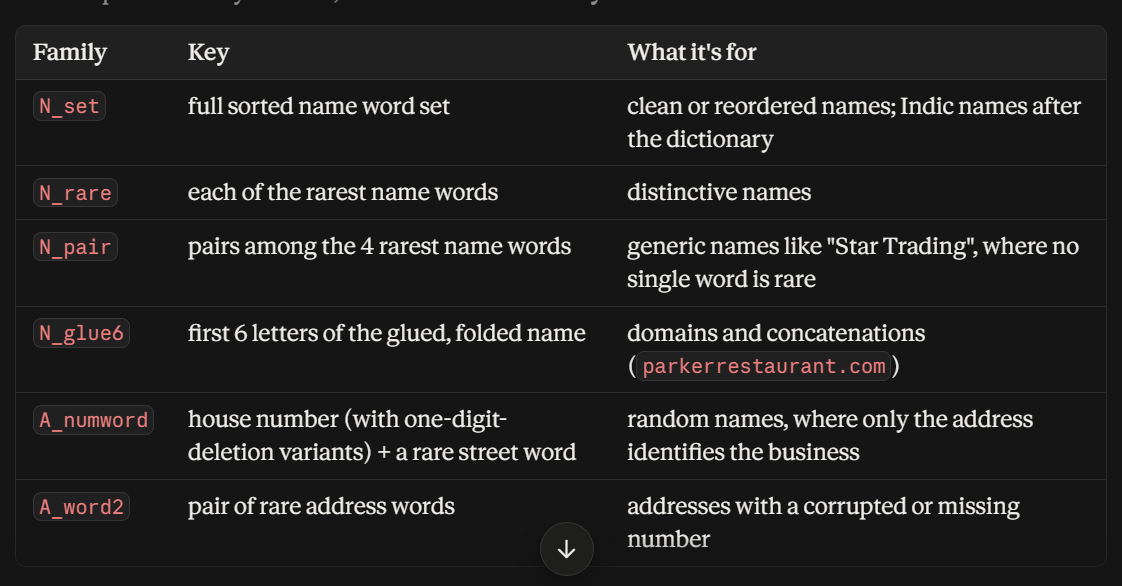

In [18]:
import re, unicodedata, numpy as np, pandas as pd, time
from collections import Counter, defaultdict
from functools import lru_cache
from rapidfuzz.fuzz import ratio

# ===== STEP 11: exact-key blocking - recall vs candidates per key family =====
U  = pd.read_parquet(f"{SAVE_DIR}/universe.parquet")
UP = pd.read_parquet(f"{SAVE_DIR}/universe_pairs.parquet")
U["idx"]   = np.arange(len(U), dtype=np.int64)
U["toks"]  = U.name_toks.map(lambda s: s.split())
U["words"] = U.addr_words.map(lambda s: s.split())
U["nums"]  = U.addr_nums.map(lambda s: s.split())
id2idx = dict(zip(U.entity_id, U.idx))
BIG = np.int64(10_000_000)

FAMS = ["N_set", "N_rare", "N_pair", "N_glue6", "A_numword", "A_word2"]
FID = {f: i for i, f in enumerate(FAMS)}
CAP = 200

def del1(n):
    out = {n}
    if len(n) >= 2:
        for i in range(len(n)):
            v = n[:i] + n[i+1:]
            if v: out.add(str(int(v)))
    return out

def rec_keys(toks, words, nums, dfn, dfa, is_s1, with_addr):
    out = []
    if toks:
        out.append(("N_set", " ".join(sorted(set(toks)))))
        gl = fold("".join(toks))
        if len(gl) >= 4: out.append(("N_glue6", gl[:6]))
    r = sorted([t for t in set(toks) if is_s1 or t in dfn], key=lambda t: (dfn.get(t, 0), t))
    for t in r[:2 if is_s1 else 3]: out.append(("N_rare", t))
    top = r[:4]
    for i in range(len(top)):
        for j in range(i + 1, len(top)): out.append(("N_pair", "|".join(sorted((top[i], top[j])))))
    if with_addr:
        rw = sorted([w for w in set(words) if is_s1 or w in dfa], key=lambda w: (dfa.get(w, 0), w))[:2 if is_s1 else 3]
        for n in nums[:3]:
            for v in del1(n):
                for w in rw: out.append(("A_numword", v + "|" + w))
        for i in range(len(rw)):
            for j in range(i + 1, len(rw)): out.append(("A_word2", "|".join(sorted((rw[i], rw[j])))))
    return out

def key_table(g, gkey, dfn, dfa, is_s1, with_addr):
    I, F, K = [], [], []
    for idx, toks, words, nums in zip(g.idx.values, g.toks.values, g.words.values, g.nums.values):
        for f, k in rec_keys(toks, words, nums, dfn, dfa, is_s1, with_addr):
            I.append(idx); F.append(FID[f]); K.append(hash((gkey, f, k)))
    return pd.DataFrame({"idx": np.array(I, np.int64), "fam": np.array(F, np.int8), "key": np.array(K, np.int64)})

def group_pairs(g1, g23, gkey, dfn, dfa, with_addr):
    k1 = key_table(g1, gkey, dfn, dfa, True, with_addr)
    k23 = key_table(g23, gkey, dfn, dfa, False, with_addr)
    bs = k23.groupby("key").size()
    k23 = k23[k23.key.isin(bs[bs <= CAP].index)]
    m = k1.merge(k23, on=["key", "fam"], suffixes=["_1", "_2"])
    return m[["idx_1", "idx_2", "fam"]].drop_duplicates()

def stats_for(C, s1_idx, truth):
    codes = np.unique(C.idx_1.values * BIG + C.idx_2.values)
    rec = 100 * np.isin(truth, codes).mean()
    per = C.drop_duplicates(["idx_1", "idx_2"]).groupby("idx_1").size().reindex(s1_idx, fill_value=0)
    return rec, per.mean(), per.median(), per.quantile(0.95), per.max(), len(codes)

has_ind = lambda s: bool(re.search(r"[\u0900-\u0DFF]", s or ""))
for ctry in ["US", "India"]:
    t0 = time.time()
    Uc = U[U.country == ctry]; S1c = Uc[Uc.src == "S1"]; S23c = Uc[Uc.src != "S1"]
    parts = []
    for st in S1c.state.unique():
        g1, g23 = S1c[S1c.state == st], S23c[S23c.state == st]
        dfn = Counter(t for ts in g1.toks for t in set(ts))
        dfa = Counter(w for ws in g1.words for w in set(ws))
        parts.append(group_pairs(g1, g23, st, dfn, dfa, True))
    dfn = Counter(t for ts in S1c.toks for t in set(ts))                    # country-wide, name only
    parts.append(group_pairs(S1c, S23c[S23c.split == "no_addr"], "*", dfn, {}, False))
    C = pd.concat(parts, ignore_index=True)
    print(f"\n{'=' * 100}\n{ctry}: candidate rows {len(C):,}  ({time.time() - t0:.0f}s)")

    for split in ["dev", "check"]:
        s1_idx = S1c[S1c.split == split].idx.values
        tp = UP[(UP.country == ctry) & (UP.split == split) & UP.in_universe]
        truth = tp.s1_id.map(id2idx).values * BIG + tp.m_id.map(id2idx).values
        Cs = C[np.isin(C.idx_1.values, s1_idx)]
        rows = []
        for f in FAMS:
            r = stats_for(Cs[Cs.fam == FID[f]], s1_idx, truth); rows.append([f, *r])
        allr = stats_for(Cs, s1_idx, truth); rows.append(["UNION", *allr])
        for f in FAMS:
            r = stats_for(Cs[Cs.fam != FID[f]], s1_idx, truth)
            rows.append([f"UNION minus {f}", *r])
        print(f"\n--- {ctry} | {split} | S1={len(s1_idx):,} | true pairs={len(truth):,} ---")
        print(pd.DataFrame(rows, columns=["family", "recall%", "cand_mean", "cand_med", "cand_p95", "cand_max",
                                          "total_pairs"]).round(2).to_string(index=False))

        # recall by pair type (union)
        codes = np.unique(Cs.idx_1.values * BIG + Cs.idx_2.values)
        hit = np.isin(truth, codes)
        mrec = U.set_index("entity_id").loc[tp.m_id]
        srec = U.set_index("entity_id").loc[tp.s1_id]
        indic = mrec.name.map(has_ind).values
        noaddr = (mrec.split == "no_addr").values
        dead = np.array([len(set(a) & set(b)) == 0 for a, b in zip(srec.toks.values, mrec.toks.values)])
        cat = np.where(noaddr, "no_addr", np.where(indic, "indic", np.where(dead, "name_dead", "normal")))
        print("union recall by pair type:",
              {c: f"{100*hit[cat == c].mean():.1f}% (n={int((cat == c).sum()):,})" for c in np.unique(cat)})

        if split == "dev":
            miss = np.where(~hit)[0]
            print("examples of MISSED true pairs (S1 → match):")
            for i in np.random.RandomState(0).choice(miss, min(15, len(miss)), replace=False):
                print(f"   {srec.name.iloc[i]} || {srec.addr.iloc[i]}")
                print(f"   → {mrec.name.iloc[i]} || {mrec.addr.iloc[i]}")


US: candidate rows 77,607,156  (52s)

--- US | dev | S1=218,376 | true pairs=755,092 ---
               family  recall%  cand_mean  cand_med  cand_p95  cand_max  total_pairs
                N_set    64.05      11.17       3.0      63.0       245      2438329
               N_rare    54.55     109.01      72.0     305.0       660     23804724
               N_pair    76.77      36.46       7.0     214.0       864      7962549
              N_glue6    54.92      33.37       6.0     181.0       312      7287179
            A_numword    82.71     116.07      60.0     401.0      1207     25346610
              A_word2    77.22      14.91       7.0      59.0       200      3255747
                UNION    99.58     282.05     256.0     628.0      1764     61593484
    UNION minus N_set    99.50     279.21     253.0     626.0      1764     60971996
   UNION minus N_rare    99.47     190.09     143.0     517.0      1417     41511216
   UNION minus N_pair    99.16     257.24     231.0     602.

    1.Recall is excellent and it generalizes. Check states (never used to design anything) are within about 0.4 points of dev states. That's our first real evidence the keys aren't overfit.

    But there are far too many candidates. About 280 per S1 on the 1.73M test S1 records would be around 480M pairs for the model to score. We need roughly 20–50.

Ablation shows what's redundant:
    N_rare is nearly useless. Removing it costs 0.1 points (US) / 0.5 points (India) of recall but saves about 90 candidates per S1 in the US. Drop it.

    A_numword is the most valuable (−1.7 points US without it) and also the noisiest (about 116 candidates per S1). The one-digit-deletion variants on short numbers create generic keys like 7|oak. Tighten it: only apply deletions to numbers with 3+ digits.

    N_set, N_pair, N_glue6 and A_word2 each add a little unique recall at modest cost. Keep them.

    Candidate counts grow with state size (India check states are smaller, so 119 vs 245). A fixed block cap therefore behaves differently per state. A fixed top-K per S1 doesn't, which makes it more robust for unseen data.

What's still missed--->

    Empty address + generic name: Choice LLC Center, Beacon Co Center, CARDIOLOGY L.L.C.-SERVICES. The only shared word (choice, cardiology) is common country-wide, so the cap dropped it. This is acceptable: with F0.5, the model should rarely predict these anyway, because with no address and a generic name there isn't enough evidence to be precise.

    Glued and reordered: smarthayesxcel.com vs Hayes Smart Xcel. The prefix key fails because the word order changed. Character n-grams handle this.

    Typos everywhere: Naeo Group, 484 Summer Oak, Paasdena vs Nova Group, 4919 Summer Oak, Pasadena. Fuzzy similarity is needed.

    India random names with sparse addresses: Veramiraxylo || HAVELI, STATURE, PUNE. The rare-word pair picked differs between the two sides. Fuzzy address similarity helps.

    India name_dead is the weakest category (89.5%). It's mostly random names with stripped addresses.
The plan: keys, then rank, then top-K

Exact keys give high recall cheaply. Then a cheap similarity score ranks each S1's candidates, and we keep only the top K. That's standard two-stage blocking, and it makes the model's workload fixed and predictable.

**Step 12: Prune families, rank with cheap similarity, measure recall@K**

    Regenerate candidates without N_rare, with one-digit deletions only for numbers of 3+ digits.

    Score every candidate pair with two unsupervised similarities (TF-IDF fitted on the records themselves, no labels):

    name: character 3-gram TF-IDF cosine. Robust to typos, glued names, word order and any language.

    address: word TF-IDF cosine on parsed address words + numbers.

Compare ranking formulas:
    name, addr, sum, max
    
    sum_imp: sum, but when either address is empty, reuse the name score in place of the missing address score, so empty-address matches aren't unfairly pushed down
Report recall@K for K = 5, 10, 20, 30, 50, 100, per country and split, plus recall by pair type.
python

In [19]:
# ===== STEP 12: prune families + rank candidates by cheap TF-IDF similarity -> recall@K =====
from sklearn.feature_extraction.text import TfidfVectorizer
import gc

try: del C
except NameError: pass
gc.collect()

def rec_keys(toks, words, nums, dfn, dfa, is_s1, with_addr):        # redefined: no N_rare, tighter A_numword
    out = []
    if toks:
        out.append(("N_set", " ".join(sorted(set(toks)))))
        gl = fold("".join(toks))
        if len(gl) >= 4: out.append(("N_glue6", gl[:6]))
    r = sorted([t for t in set(toks) if is_s1 or t in dfn], key=lambda t: (dfn.get(t, 0), t))
    top = r[:4]
    for i in range(len(top)):
        for j in range(i + 1, len(top)): out.append(("N_pair", "|".join(sorted((top[i], top[j])))))
    if with_addr:
        rw = sorted([w for w in set(words) if is_s1 or w in dfa], key=lambda w: (dfa.get(w, 0), w))[:2 if is_s1 else 3]
        for n in nums[:3]:
            for v in (del1(n) if len(n) >= 3 else {n}):
                for w in rw: out.append(("A_numword", v + "|" + w))
        for i in range(len(rw)):
            for j in range(i + 1, len(rw)): out.append(("A_word2", "|".join(sorted((rw[i], rw[j])))))
    return out

def gen_candidates(ctry):
    Uc = U[U.country == ctry]; S1c = Uc[Uc.src == "S1"]; S23c = Uc[Uc.src != "S1"]
    parts = []
    for st in S1c.state.unique():
        g1, g23 = S1c[S1c.state == st], S23c[S23c.state == st]
        dfn = Counter(t for ts in g1.toks for t in set(ts))
        dfa = Counter(w for ws in g1.words for w in set(ws))
        parts.append(group_pairs(g1, g23, st, dfn, dfa, True))
    dfn = Counter(t for ts in S1c.toks for t in set(ts))
    parts.append(group_pairs(S1c, S23c[S23c.split == "no_addr"], "*", dfn, {}, False))
    C = pd.concat(parts, ignore_index=True)
    fam_recall_src = C
    return C.drop_duplicates(["idx_1", "idx_2"])[["idx_1", "idx_2"]].reset_index(drop=True), C

def rowdot(X, a, b, chunk=2_000_000):
    out = np.empty(len(a), np.float32)
    for s in range(0, len(a), chunk):
        out[s:s + chunk] = np.asarray(X[a[s:s + chunk]].multiply(X[b[s:s + chunk]]).sum(axis=1)).ravel()
    return out

def ranks_within(i1, score):
    order = np.lexsort((-score, i1))
    i1s = i1[order]
    starts = np.r_[0, np.flatnonzero(np.diff(i1s)) + 1]
    lens = np.diff(np.r_[starts, len(i1s)])
    rank = np.arange(len(i1s)) - np.repeat(starts, lens)
    return order, rank

def pair_types(tp):
    mrec = U.set_index("entity_id").loc[tp.m_id]; srec = U.set_index("entity_id").loc[tp.s1_id]
    indic = mrec.name.map(has_ind).values; noaddr = (mrec.split == "no_addr").values
    dead = np.array([len(set(a) & set(b)) == 0 for a, b in zip(srec.toks.values, mrec.toks.values)])
    return np.where(noaddr, "no_addr", np.where(indic, "indic", np.where(dead, "name_dead", "normal")))

KS = [5, 10, 20, 30, 50, 100]
for ctry in ["US", "India"]:
    t0 = time.time()
    Cu, Cfam = gen_candidates(ctry)
    print(f"\n{'=' * 100}\n{ctry}: unique candidate pairs {len(Cu):,}  ({time.time() - t0:.0f}s)")

    # ---- per-family recall after pruning (dev) ----
    for split in ["dev", "check"]:
        S1s = U[(U.country == ctry) & (U.src == "S1") & (U.split == split)].idx.values
        tp = UP[(UP.country == ctry) & (UP.split == split) & UP.in_universe]
        truth = tp.s1_id.map(id2idx).values * BIG + tp.m_id.map(id2idx).values
        sub = Cfam[np.isin(Cfam.idx_1.values, S1s)]
        fr = {f: round(100 * np.isin(truth, np.unique(sub[sub.fam == FID[f]].idx_1.values * BIG +
                                                       sub[sub.fam == FID[f]].idx_2.values)).mean(), 2)
              for f in ["N_set", "N_pair", "N_glue6", "A_numword", "A_word2"]}
        print(f"  {split} per-family recall after pruning: {fr}")
    del Cfam; gc.collect()

    # ---- cheap similarity scores (TF-IDF fitted on this country's records, no labels) ----
    Uc = U[U.country == ctry]
    pos = np.full(len(U), -1, np.int64); pos[Uc.idx.values] = np.arange(len(Uc))
    vn = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 3), min_df=2, dtype=np.float32, sublinear_tf=True)
    Xn = vn.fit_transform(Uc.name_toks.values).tocsr()
    va = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False, min_df=2,
                         dtype=np.float32, sublinear_tf=True)
    Xa = va.fit_transform((Uc.addr_words + " " + Uc.addr_nums).str.strip().values).tocsr()
    a, b = pos[Cu.idx_1.values], pos[Cu.idx_2.values]
    sn = rowdot(Xn, a, b); sa = rowdot(Xa, a, b)
    both_addr = (Uc.addr_words.values[a] != "") & (Uc.addr_words.values[b] != "")
    SC = {"name": sn, "addr": sa, "sum": sn + sa, "max": np.maximum(sn, sa),
          "sum_imp": sn + np.where(both_addr, sa, sn)}
    print(f"  scoring done ({time.time() - t0:.0f}s)")

    for split in ["dev", "check"]:
        S1s = U[(U.country == ctry) & (U.src == "S1") & (U.split == split)].idx.values
        tp = UP[(UP.country == ctry) & (UP.split == split) & UP.in_universe]
        truth = tp.s1_id.map(id2idx).values * BIG + tp.m_id.map(id2idx).values
        m = np.isin(Cu.idx_1.values, S1s)
        i1, i2 = Cu.idx_1.values[m], Cu.idx_2.values[m]
        ub = 100 * np.isin(truth, i1 * BIG + i2).mean()
        n_per = pd.Series(i1).value_counts().reindex(S1s, fill_value=0).values
        print(f"\n--- {ctry} | {split} | upper bound (all candidates) recall {ub:.2f}% | "
              f"candidates/S1 mean {n_per.mean():.0f} ---")
        rows = []
        best = None
        for nm, s in SC.items():
            order, rank = ranks_within(i1, s[m])
            codes = i1[order] * BIG + i2[order]
            r = {K: round(100 * np.isin(truth, codes[rank < K]).mean(), 2) for K in KS}
            rows.append([nm] + [r[K] for K in KS])
            if nm == "sum_imp": best = (codes, rank)
        print(pd.DataFrame(rows, columns=["score"] + [f"R@{K}" for K in KS]).to_string(index=False))
        print("  avg candidates kept/S1: " + "  ".join(f"K={K}: {np.minimum(n_per, K).mean():.1f}" for K in KS))

        cat = pair_types(tp)
        codes, rank = best
        for K in [20, 50]:
            hit = np.isin(truth, codes[rank < K])
            print(f"  sum_imp R@{K} by pair type:",
                  {c: f"{100*hit[cat == c].mean():.1f}%" for c in np.unique(cat)})
    del Cu, Xn, Xa, SC, sn, sa; gc.collect()


US: unique candidate pairs 44,722,194  (51s)
  dev per-family recall after pruning: {'N_set': np.float64(64.05), 'N_pair': np.float64(76.77), 'N_glue6': np.float64(54.92), 'A_numword': np.float64(82.69), 'A_word2': np.float64(77.22)}
  check per-family recall after pruning: {'N_set': np.float64(64.5), 'N_pair': np.float64(78.42), 'N_glue6': np.float64(67.2), 'A_numword': np.float64(81.09), 'A_word2': np.float64(45.2)}
  scoring done (104s)

--- US | dev | upper bound (all candidates) recall 99.47% | candidates/S1 mean 185 ---
  score   R@5  R@10  R@20  R@30  R@50  R@100
   name 67.04 80.08 86.56 89.69 93.21  96.32
   addr 82.83 90.54 93.60 94.71 95.73  96.95
    sum 89.93 97.59 98.37 98.69 98.97  99.23
    max 74.91 86.73 91.97 94.24 96.40  98.45
sum_imp 77.96 89.65 94.37 96.34 97.66  99.01
  avg candidates kept/S1: K=5: 5.0  K=10: 9.9  K=20: 19.5  K=30: 28.6  K=50: 45.2  K=100: 79.5
  sum_imp R@20 by pair type: {np.str_('name_dead'): '83.5%', np.str_('no_addr'): '90.8%', np.str_('nor

What the numbers say

1. Pruning worked.

    US: candidates per S1 dropped from 282 to 185, and the upper-bound recall barely moved (99.58 → 99.47).

    India: 245 → 172, with recall 98.14 → 97.63. That −0.5 is the N_rare removal, as the ablation predicted.
    
    Tightening A_numword cost essentially nothing (82.71 → 82.69).

2. The plain sum (name + address similarity) is clearly the best ranking:

    Only about 20 candidates per S1 keep nearly all the recall. That's a 9× reduction from 185, and a very manageable workload for the model.

    Dev and check agree again, so the ranking generalizes.

    Name alone and address alone are each much weaker. Combining the two signals is what works.

3. My sum_imp was a mistake. It's worse than plain sum everywhere. Doubling the name score for empty-address pairs let the whole country's pool of no-address records push true in-state matches out of the top K. The right fix is a separate quota: keep the top K by sum among in-state candidates, plus a small top K by name among no-address candidates. Then the two groups don't compete for the same slots.

4. Where recall is still lost (mainly India):

    The blocking upper bound of 97.6% means about 2.4 points of India's true pairs never become candidates at all, mostly name_dead (random names + stripped addresses) and some no_addr.
Ranking loses about 1.7 more points at K=20.

Next: raise the upper bound with nearest-neighbour search

Since sum is the best ranking signal, we can search for the top neighbours by that same score directly, instead of only ranking what the exact keys happened to find. That's a nearest-neighbour search on the combined name+address TF-IDF vector within each state.

**Step 13: Add TF-IDF nearest-neighbour retrieval plus quota-based top-K
Regenerate the exact-key candidates (same as Step 12)**

    Add nearest neighbours, using sparse_dot_topn, a fast multi-threaded sparse top-N library (MIT license):

    in-state: top 20 S2/S3 per S1 by the combined name+address vector

    no-address pool: top 5 per S1 by name vector, country-wide

Report the upper bound for keys only / neighbours only / union, to show how much each adds.

Quota selection: top K1 in-state by sum + top K2 no-address by name. Recall and average workload for a grid of K1/K2, plus recall by pair type.

In [21]:
# ===== STEP 13: TF-IDF nearest-neighbour retrieval + quota-based top-K =====
!pip -q install sparse_dot_topn
import os, sparse_dot_topn as sdt
from scipy.sparse import hstack

NTH = os.cpu_count()
KNN_STATE, KNN_NOADDR = 20, 5

def topn(A, B, n, thr=0.05, chunk=20_000):
    """Top-n cosine neighbours of each row of A among rows of B (both L2-normalised CSR)."""
    BT = B.T.tocsr()
    rows, cols = [], []
    for s in range(0, A.shape[0], chunk):
        R = sdt.sp_matmul_topn(A[s:s + chunk], BT, top_n=n, threshold=thr, sort=True, n_threads=NTH).tocoo()
        rows.append(R.row.astype(np.int64) + s); cols.append(R.col.astype(np.int64))
    return np.concatenate(rows), np.concatenate(cols)

U["is_noaddr"] = (U.split == "no_addr").values
IS_NOADDR = U.is_noaddr.values
K1S, K2S = [10, 20, 30, 50], [0, 3, 5]

for ctry in ["US", "India"]:
    t0 = time.time()
    Cu, Cfam = gen_candidates(ctry); del Cfam; gc.collect()
    Uc = U[U.country == ctry].reset_index(drop=True)
    pos = np.full(len(U), -1, np.int64); pos[Uc.idx.values] = np.arange(len(Uc))
    vn = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 3), min_df=2, dtype=np.float32, sublinear_tf=True)
    Xn = vn.fit_transform(Uc.name_toks.values).tocsr()
    va = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False, min_df=2,
                         dtype=np.float32, sublinear_tf=True)
    Xa = va.fit_transform((Uc.addr_words + " " + Uc.addr_nums).str.strip().values).tocsr()
    Xc = (hstack([Xn, Xa]).tocsr() * np.float32(1 / np.sqrt(2)))
    print(f"\n{'=' * 100}\n{ctry}: key candidates {len(Cu):,} | TF-IDF ready ({time.time() - t0:.0f}s)")

    # ---- nearest neighbours ----
    kr, kc = [], []
    is_s1 = (Uc.src == "S1").values
    for st in Uc.state[is_s1].unique():
        p1 = np.flatnonzero(is_s1 & (Uc.state.values == st))
        p2 = np.flatnonzero(~is_s1 & (Uc.state.values == st) & ~Uc.is_noaddr.values)
        r, c = topn(Xc[p1], Xc[p2], KNN_STATE); kr.append(p1[r]); kc.append(p2[c])
    p1 = np.flatnonzero(is_s1); p2 = np.flatnonzero(Uc.is_noaddr.values)
    r, c = topn(Xn[p1], Xn[p2], KNN_NOADDR); kr.append(p1[r]); kc.append(p2[c])
    K = pd.DataFrame({"idx_1": Uc.idx.values[np.concatenate(kr)], "idx_2": Uc.idx.values[np.concatenate(kc)]})
    print(f"  kNN pairs {len(K):,} ({time.time() - t0:.0f}s)")

    key_codes = Cu.idx_1.values * BIG + Cu.idx_2.values
    knn_codes = K.idx_1.values * BIG + K.idx_2.values
    ALL = pd.concat([Cu, K]).drop_duplicates().reset_index(drop=True)
    i1, i2 = ALL.idx_1.values, ALL.idx_2.values
    a, b = pos[i1], pos[i2]
    sn = rowdot(Xn, a, b); sa = rowdot(Xa, a, b); na = IS_NOADDR[i2]
    print(f"  union pairs {len(ALL):,}, scored ({time.time() - t0:.0f}s)")

    for split in ["dev", "check"]:
        S1s = U[(U.country == ctry) & (U.src == "S1") & (U.split == split)].idx.values
        tp = UP[(UP.country == ctry) & (UP.split == split) & UP.in_universe]
        truth = tp.s1_id.map(id2idx).values * BIG + tp.m_id.map(id2idx).values
        ub_key = 100 * np.isin(truth, key_codes).mean()
        ub_knn = 100 * np.isin(truth, knn_codes).mean()
        m = np.isin(i1, S1s)
        ub_all = 100 * np.isin(truth, i1[m] * BIG + i2[m]).mean()
        print(f"\n--- {ctry} | {split} --- upper bound: keys {ub_key:.2f}% | kNN {ub_knn:.2f}% | UNION {ub_all:.2f}%")

        ms, mn = m & ~na, m & na                                    # in-state vs no-address pools
        o_s, r_s = ranks_within(i1[ms], (sn + sa)[ms]); c_s = (i1[ms] * BIG + i2[ms])[o_s]
        o_n, r_n = ranks_within(i1[mn], sn[mn]);        c_n = (i1[mn] * BIG + i2[mn])[o_n]
        rows, best = [], None
        for K1 in K1S:
            for K2 in K2S:
                codes = np.concatenate([c_s[r_s < K1], c_n[r_n < K2]])
                rows.append([K1, K2, round(100 * np.isin(truth, codes).mean(), 2), round(len(codes) / len(S1s), 1)])
                if (K1, K2) == (20, 3): best = codes
        print(pd.DataFrame(rows, columns=["K1_state", "K2_noaddr", "recall%", "avg_kept/S1"]).to_string(index=False))
        cat = pair_types(tp); hit = np.isin(truth, best)
        print("  recall by pair type @ (K1=20, K2=3):",
              {c: f"{100*hit[cat == c].mean():.1f}%" for c in np.unique(cat)})
    del Cu, K, ALL, Xn, Xa, Xc, sn, sa; gc.collect()


US: key candidates 44,722,194 | TF-IDF ready (72s)
  kNN pairs 6,037,370 (437s)
  union pairs 47,379,904, scored (461s)

--- US | dev --- upper bound: keys 99.47% | kNN 98.62% | UNION 99.70%
 K1_state  K2_noaddr  recall%  avg_kept/S1
       10          0    94.41         10.0
       10          3    98.11         13.0
       10          5    98.28         15.0
       20          0    94.71         20.0
       20          3    98.41         23.0
       20          5    98.58         25.0
       30          0    94.94         29.6
       30          3    98.64         32.6
       30          5    98.81         34.6
       50          0    95.02         46.7
       50          3    98.72         49.7
       50          5    98.90         51.7
  recall by pair type @ (K1=20, K2=3): {np.str_('name_dead'): '94.0%', np.str_('no_addr'): '78.3%', np.str_('normal'): '99.9%'}

--- US | check --- upper bound: keys 99.01% | kNN 98.69% | UNION 99.62%
 K1_state  K2_noaddr  recall%  avg_kept/S1
     

Decisions

1. Freeze the blocking design:

exact keys: N_set, N_pair, N_glue6, A_numword (deletions only for 3+ digit numbers), A_word2
plus TF-IDF neighbours: top 20 in-state (combined name+address), top 10 no-address (name)
rank by name + address similarity, keep K1=30 in-state + K2=5 no-address, about 34 per S1
recall about 98.8% (US) and 97.8–98.8% (India). The extra margin over K1=20 is a safety buffer for the private set.

2. Skip embeddings for blocking (Step 14). The remaining misses are no_addr (generic name, no address) and random names with thin addresses. An embedding model can't find evidence that isn't in the text. Indic is already at 99.5%+. So it would cost a lot of GPU time for little gain. We can still consider it later as a model feature.

3. A simple, generic partition rule, which also answers France:

if a state is detected (US/India) → partition by state
otherwise (France, or any unknown country) → one block per country

France has 259k S1 × 1.43M S2/S3, about the same scale as Maharashtra, which we just handled. So France needs no special code, only the generic rule. Records whose state didn't parse join the no-address pool, which covers the 0.08% lost earlier.

4. The remaining losses are mostly cases the model couldn't match confidently anyway (no address plus a generic name). Under F0.5 that's the right place to lose recall.

Speed (from what we saw: 7 min US, 16 min India)

For the full runs we'll ignore very common tokens in neighbour search and only run it for S1 records whose key candidates look weak. We'll measure the actual speed-up in the full train run.